In [1]:

#  # Squipy Xenium spatial melanoma neighbourhood and gene of interest analysis

# ## Import packages

In [2]:
import anndata as ad
import os
import numpy as np
import pandas as pd

import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

from pathlib import Path
import shutil

import squidpy as sq
from IPython.display import display
import warnings
warnings.filterwarnings("ignore") 

import scipy.sparse as sparse
from scipy.io import mmread

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib import rc_context

import random
# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

#import dask
#dask.config.set({"dataframe.query-planning": True})


# ## Set file paths and read in xenium data

/home/nnataren/miniforge3/envs/banksy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [3]:
#############
#   TEST    #
#############

## Set the dataset_name and related settings to use during this analysis
dataset_name = "GR_lung_non_res_roi"

pca_label = "35"
pca_dims = int(pca_label)
pca_dims = [pca_dims]

lambda_label = "0.20"
lambda_list = [float(lambda_label)]

res_label = "0.50"
resolutions = [float(res_label)]

nbr_weight_decay = "scaled_gaussian"

# Keys to specify coordinate indexes in the anndata Object
coord_keys = ('x', 'y', 'xy')


### Create directories for processed and output data and set the dataset_name

In [4]:
# #############
# #   TEST    #
# #############

# #  Create a path for raw data
# raw_path = f"data/xenium/raw_data/"

# # Create path for processed data
# processed_path = f"data/xenium/processed/anndata_conversion_test/{dataset_name}/"

# if not os.path.isdir(processed_path):
#     os.makedirs(processed_path)
#     print(f"Directory '{processed_path}' created successfully.")
# else:
#     print(f"Directory '{processed_path}' already exists.")


# # Create path for output data
# output_path = f"data/xenium/output/anndata_conversion_test/{dataset_name}/"

# if not os.path.isdir(output_path):
#     os.makedirs(output_path)
#     print(f"Directory '{output_path}' created successfully.")
# else:
#     print(f"Directory '{output_path}' already exists.")

# # Create a path for QC results
# qc_path = f"data/xenium/output/anndata_conversion_test/{dataset_name}/QC"

# if not os.path.isdir(qc_path):
#     os.makedirs(qc_path)
#     print(f"Directory '{qc_path}' created successfully.")
# else:
#     print(f"Directory '{qc_path}' already exists.")

In [5]:
# # ## Set the dataset_name and related settings to use during this analysis
# import json
# import argparse

# parser = argparse.ArgumentParser(prog="used to parse arguments form 00_QC_xenium_spatial.py to run on slurm")
# parser.add_argument("--config", type=str, help="Provide a JSON config file for each Xenium sample", required=True)
# args = parser.parse_args()

# with open(args.config) as f:
#     cfg = json.load(f)

# # Derive the values from the config JSON

# dataset_name = cfg["dataset_name"]
# pca_label = cfg["pca_label"]
# pca_dims = [int(pca_label)]
# lambda_label = cfg["lambda_label"]
# lambda_list = [float(lambda_label)]
# res_label = cfg["res_label"]
# resolutions = [float(res_label)]
# nbr_weight_decay = cfg["nbr_weight_decay"]

# # Keys to specify coordinate indexes in the anndata Object
# coord_keys = tuple(cfg["coord_keys"])

In [6]:
## Create a base path
base_dir = "data/xenium"

## Create a path to the raw data e.g., unprocessed anndata files
raw_path = os.path.join(base_dir, "raw_data")

if not os.path.isdir(raw_path):
    os.makedirs(raw_path)
    print(f"Directory '{raw_path} successfully.")
    
else:
    print(f"Directory '{raw_path} exists.")

## Create path for processed data e.g., the pre-clustered but unfiltered anndata files
processed_path = os.path.join(base_dir,f"processed/{dataset_name}")

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
    
else:
    print(f"Directory '{processed_path}' already exists.")

## Create a path for output data
output_path = os.path.join(base_dir,f"output/{dataset_name}")

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
    
else:
    print(f"Directory '{output_path}' already exists.")

## Create a path for QC results
qc_path = f"data/xenium/output/QC_testing/{dataset_name}"

if not os.path.isdir(qc_path):
    os.makedirs(qc_path)
    print(f"Directory '{qc_path}' created successfully.")
else:
    print(f"Directory '{qc_path}' already exists.")


# ## Load Xenium data
# Allocate path to folder and the file name of the designated AnnaData Object (in `.h5ad` format) <br>

Directory 'data/xenium/raw_data exists.
Directory 'data/xenium/processed/GR_lung_non_res_roi' already exists.
Directory 'data/xenium/output/GR_lung_non_res_roi' already exists.
Directory 'data/xenium/output/QC_testing/GR_lung_non_res_roi' already exists.


In [7]:
## Read in the raw AnnData file
adata = ad.read_h5ad(f"{raw_path}/{dataset_name}_raw.h5ad")
#output_path = f"data/xenium/processed/{dataset_name}_xy.h5ad"
adata.obs_keys()

# Create 'xy' spatial coordinates from adata.obs
adata.obsm['xy'] = np.vstack([adata.obs['x'], adata.obs['y']]).T

In [8]:
# Filter out cells with zero counts
adata = adata[adata.obs['nCount_Xenium'] > 0].copy()

In [9]:
# Function to check the float size of the adata.obsm data
from banksy_utils.object_downcasting_utils import check_float, downcast_float
check_float(adata)

# Function to downcast adata.obsm to 32 bit and check that the resulting array is an N-dimensional array
downcast_float(adata, "float32")

xy: shape=(30203, 2), dtype=float64
AnnData object with n_obs × n_vars = 30203 × 304
    obs: 'sample_name', 'x', 'y', 'cell_area', 'nucleus_area', 'transcript_counts', 'nucleus_count', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'segmentation_method', 'nCount_Xenium', 'nFeature_Xenium'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'xy'
    layers: 'counts' object downcast to float32


In [10]:
# Check the float size of the adata.obsm data after downcasting to make sure the float type is correct
check_float(adata)

xy: shape=(30203, 2), dtype=float32


In [ ]:
# Write the downcast file to AnnData format 
import anndata as ad
adata.write_h5ad(
    #filename = f"data/xenium/processed/{dataset_name}_float_32.h5ad",
    filename = f"{processed_path}/{dataset_name}_raw_float_32.h5ad",
    compression="gzip"
    )

# Define float adata file
float_adata = f"{dataset_name}_raw_float_32.h5ad"

In [ ]:
f"{processed_path}{dataset_name}_raw_float_32.h5ad"

'data/xenium/processed/GR_lung_non_res_roiGR_lung_non_res_roi_raw_sopa_float_32.h5ad'

In [13]:
from banksy_utils.load_data import load_adata, display_adata

# To either load data from .h5ad directly or convert raw data to .h5ad format
load_adata_directly = True

# Keys to specify coordinate indexes in the anndata Object
coord_keys = ('x', 'y', 'xy')

raw_y, raw_x, adata = load_adata(filepath=processed_path, adata_filename=float_adata, load_adata_directly=True, coord_keys=('x','y','xy'))

Looking for data/xenium/processed/GR_lung_non_res_roi/GR_lung_non_res_roi_raw_sopa_float_32.h5ad
Attemping to read Annadata directly
Anndata file successfully loaded!
Attempting to concatenate spatial x-y under adata.obsm[xy]
Concatenation success!


In [14]:
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calulates QC metrics and put them in place to the adata object
sc.pp.calculate_qc_metrics(adata, 
                           qc_vars=["mt"], 
                           log1p=True, 
                           inplace=True,
                           percent_top=[10,20]
                           )

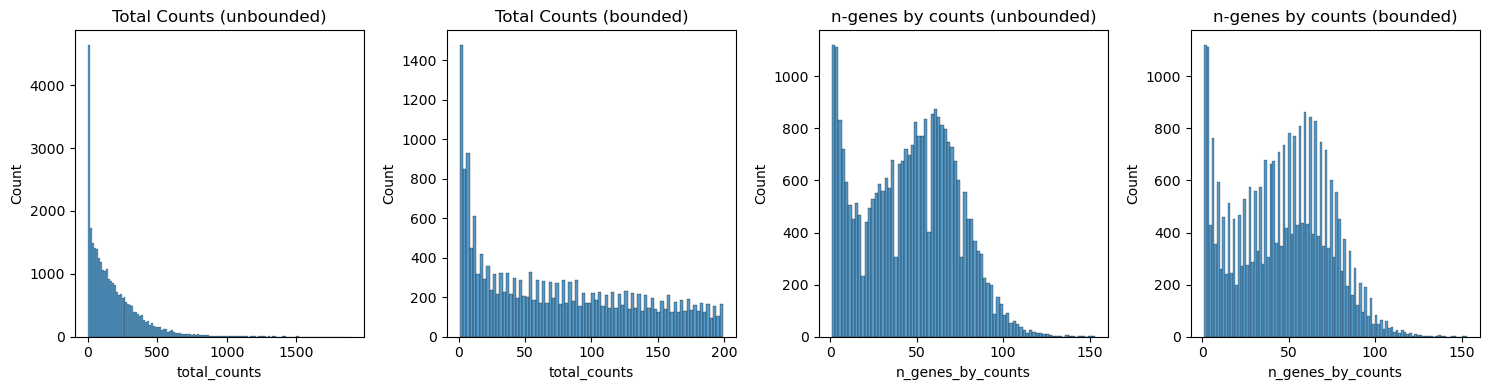

In [15]:
from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions

# bin options for fomratting histograms
# Here, we set 'auto' for 1st figure, 80 bins for 2nd figure. and so on
hist_bin_options = ['auto', 80, 80, 100]

plot_qc_hist(adata, 
         total_counts_cutoff = 200, # for visualization
         n_genes_high_cutoff = 1000, # for visualization
         n_genes_low_cutoff = 0, # for visualization
         bin_options = hist_bin_options)

plt.savefig(os.path.join(qc_path, f"banksy_counts_and_genes_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

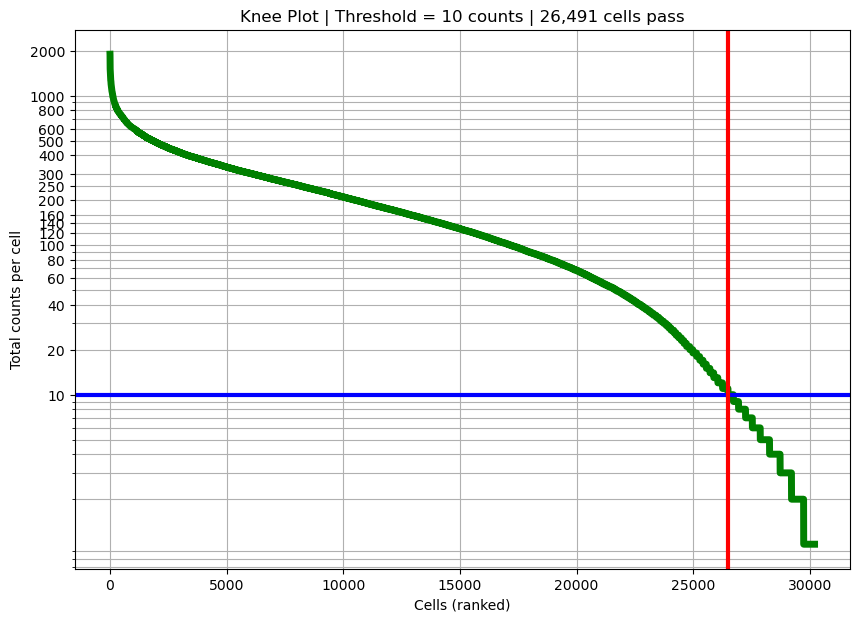

Cells passing threshold of 10 counts: 26,491 / 30,203 (87.7%)


In [16]:
# ## Filter 1 - minimum number of transcripts filter
# ### Plot knee plot (log10 transcripts per cell)

## from https://pachterlab.github.io/kallistobustools/tutorials/kb_getting_started/python/kb_intro_2_python/

threshold = 10
knee = np.sort((np.array(adata.X.sum(axis=1))).flatten())[::-1]
#knee = np.sort(adata.obs['nCount_Xenium'].values)[::-1]
#knee = np.sort(np.asarray(adata.X.sum(axis=1)).flatten())[::-1]

cell_set = np.arange(len(knee))
#num_cells = cell_set[knee > threshold] [::-1][0]
num_cells = (knee > threshold).sum()

fig, ax = plt.subplots(figsize=(10, 7))

#ax.loglog(cell_set, knee, linewidth=5, color="g")
ax.semilogy(knee, linewidth =5, color="g")
#ax.loglog(cell_set, knee, linewidth=5, color="g")
ax.axhline(y=threshold, linewidth=3, color="b")
ax.axvline(x=num_cells, linewidth=3, color="r")

ax.set_xlabel("Cells (ranked)")
ax.set_ylabel("Total counts per cell")

ax.set_yticks([10, 20, 40, 60, 80, 100, 120, 140, 160, 200, 250, 300, 400, 500, 600, 800, 1000, 2000])
#ax.set_yticks([10, 20, 40, 60, 80, 100, 120, 140, 160,200])
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

plt.grid(True, which="both")
plt.title(f"Knee Plot | Threshold = {threshold} counts | {num_cells:,} cells pass")
plt.savefig(os.path.join(qc_path, f"transcript_knee_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

print(f"Cells passing threshold of {threshold} counts: {num_cells:,} / {len(knee):,} ({num_cells/len(knee)*100:.1f}%)")

In [17]:
# ### Read in the raw matrix here!!
# raw_matrix = pd.read_csv(os.path.join(raw_data, "GR_lung_non_res_cell_feature_matrix.csv"))
# raw_matrix.rename(columns={raw_matrix.columns[0]: "cell_ids"}, inplace=True)

# # Defince cells IDs to check
# cell_ids = [
#     'akljhmnp-1',
#     'akljiabi-1', 
#     'aklkomhk-1',
#     'akllenhp-1',
#     'aklobaoh-1',
#     'aklocplk-1'
# ]

# # Subset the raw matric by the cells above to compare to the adata.X data for these same cells

# raw_matrix_subset = raw_matrix[raw_matrix['cell_ids'].isin(cell_ids)]

# raw_matrix_subset.to_csv(os.path.join(qc_path, 'raw_matrix_subset.csv'))


In [18]:
# # Define your cell IDs
# cell_ids = [
#     'akljhmnp-1',
#     'akljiabi-1', 
#     'aklkomhk-1',
#     'akllenhp-1',
#     'aklobaoh-1',
#     'aklocplk-1'
# ]

# # Subset adata.X for these cells
# adata_subset = adata[cell_ids, :]

# # Get the X matrix for these cells
# X_subset = adata_subset.X.toarray()  # convert sparse to dense

# # Sum counts across cells (per gene)
# gene_sums = X_subset.sum(axis=0)  # sum down rows = per gene total
# print(pd.DataFrame(gene_sums.reshape(1, -1), columns=adata.var_names))

# # Sum counts per cell (across genes)
# cell_sums = X_subset.sum(axis=1)  # sum across columns = per cell total
# print(pd.DataFrame(cell_sums, index=cell_ids, columns=['total_counts']))

# # Subset obsm for these cells
# obsm_subset = adata_subset.obsm['xy']  # or whatever key you need
# print(obsm_subset)

# # Output the full X matrix as a readable DataFrame
# X_df = pd.DataFrame(
#     X_subset,
#     index=cell_ids,
#     columns=adata.var_names
# )
# print(X_df)

# # Optionally save to CSV
# X_df.to_csv(os.path.join(qc_path, 'subset_X.csv'))




In [19]:
# #### Apply the minimum transcripts per cell mask 

## Apply a mask to retrieve cells that don't pass the filter
mask = adata.obs['nCount_Xenium'] <= threshold

# Turn the masked cells into a data frame
mask.to_frame()
mask_cells = mask.reset_index()
mask_cells = mask_cells.rename(columns={"index":"cell_id", "nCount_Xenium" : "threshold_passed"})

# Filter for the poor cells and keep these ids for future plotting
poor_cells = mask_cells[mask_cells['threshold_passed']]

# Put results for the cells passing the threshold into the object directly
adata.obs['threshold_passed'] = adata.obs['nCount_Xenium'] > threshold #True = passed

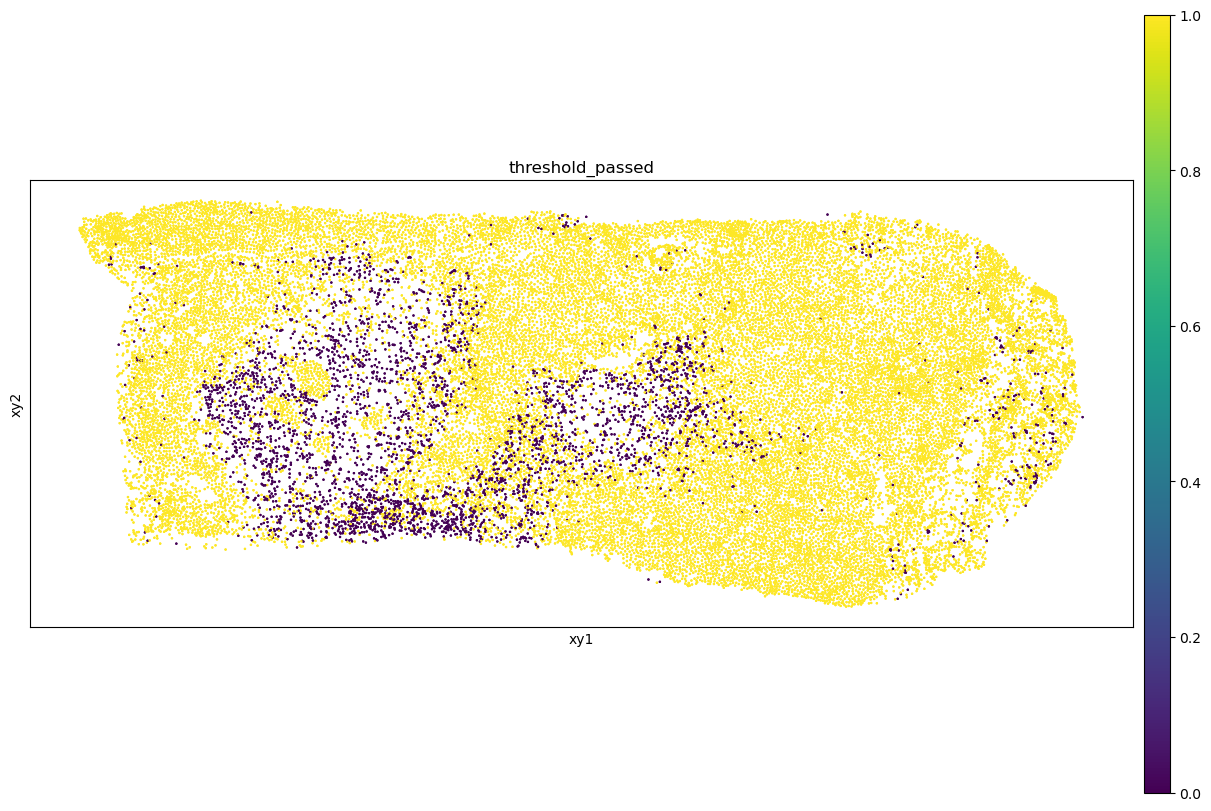

In [20]:
# #### Plot location of poor cells on tissue
adata.uns["spatial"] = {dataset_name: {}}

with rc_context({"figure.figsize": (12,8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="threshold_passed",
        shape=None,
        size=2,
        img=False
    )


plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_threshold_passed_cells_qc_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )

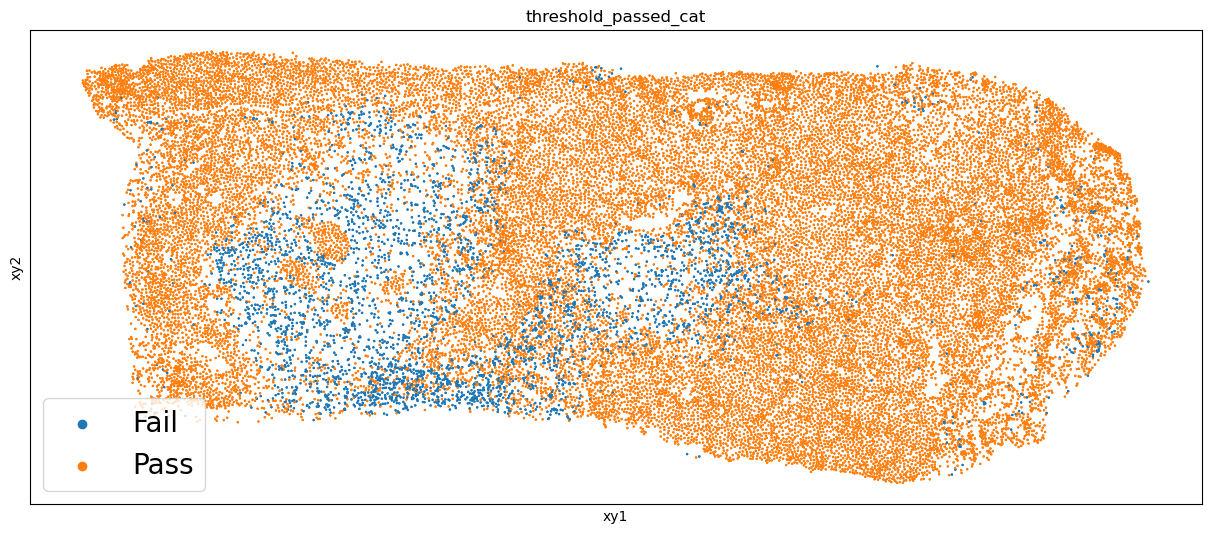

In [21]:
adata.obs["threshold_passed_cat"] = adata.obs["threshold_passed"].map({True: "Pass", False: "Fail"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="threshold_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)




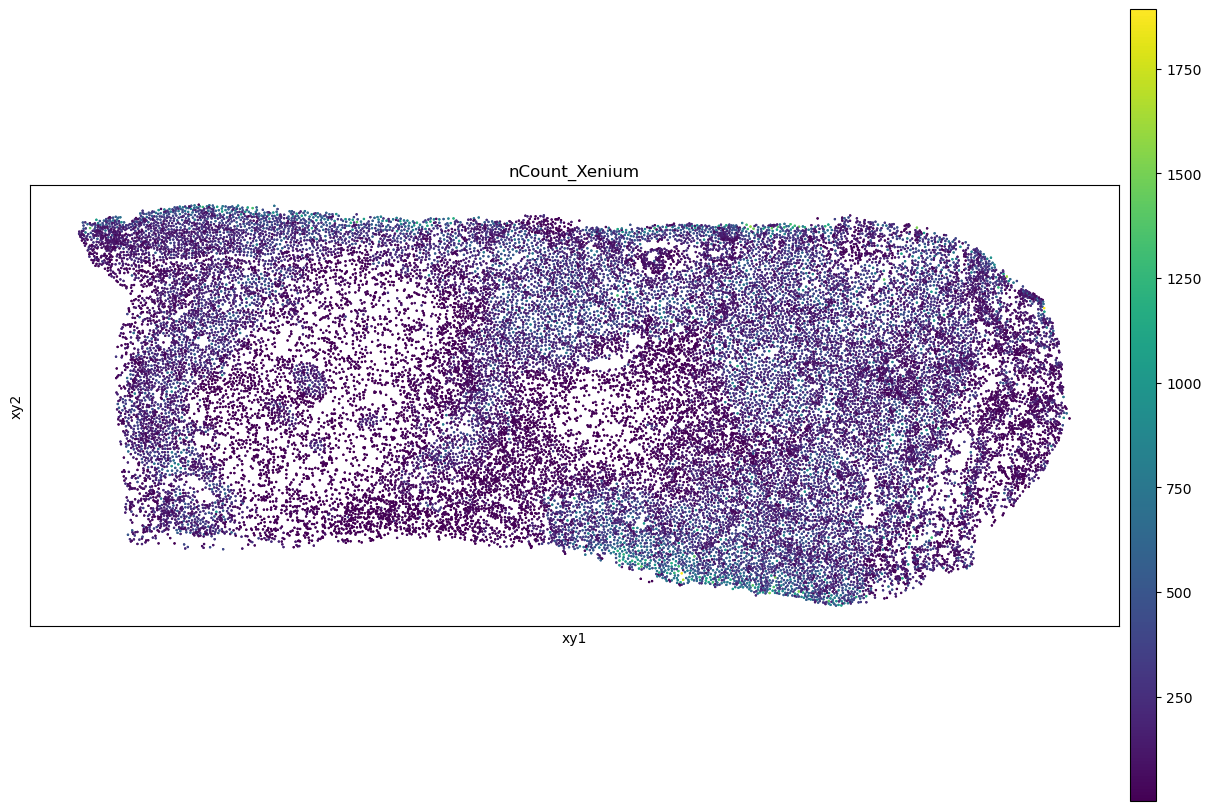

In [22]:
# #### Plot of total transripts per cell across sample (rainbow in viridis)

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].max(),
        #vmax= 300,
        palette="gist_stern"
    )

#
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_threshold_passed_cells_qc_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )

In [23]:
# obs_data= adata.obs
# obs_data.to_csv(f"{processed_path}/obs_data_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

# var_data= adata.var
# var_data.to_csv(f"{processed_path}/var_data_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

# uns_data= adata.uns
# uns_data.to_csv(f"{processed_path}/uns_data_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

# obsm_data= adata.obsm
# obsm_data.to_csv(f"{processed_path}/obsm_data_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

In [24]:
# ### Check a slice of cells to inspect counts

# # Define cells to look at
# cell_ids = [
#     'akljhmnp-1',
#     'akljiabi-1', 
#     'aklkomhk-1',
#     'akllenhp-1',
#     'aklobaoh-1',
#     'aklocplk-1'
# ]

# # Subset obs for these cells
# obs_subset = adata.obs.loc[cell_ids]
# print(obs_subset)

# # Check specific columns
# print(obs_subset[['nCount_Xenium', 'nCount_SCT', 'total_counts']])


# obs_subset.to_csv(f"{qc_path}/obs_subset_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

In [25]:
# # Define your cell IDs
# cell_ids = [
#     'akljhmnp-1',
#     'akljiabi-1', 
#     'aklkomhk-1',
#     'akllenhp-1',
#     'aklobaoh-1',
#     'aklocplk-1'
# ]

# # Subset adata.X for these cells
# adata_subset = adata[cell_ids, :]

# # Get the X matrix for these cells
# X_subset = adata_subset.X.toarray()  # convert sparse to dense

# # Sum counts across cells (per gene)
# gene_sums = X_subset.sum(axis=0)  # sum down rows = per gene total
# print(pd.DataFrame(gene_sums.reshape(1, -1), columns=adata.var_names))

# # Sum counts per cell (across genes)
# cell_sums = X_subset.sum(axis=1)  # sum across columns = per cell total
# print(pd.DataFrame(cell_sums, index=cell_ids, columns=['total_counts']))

# # Subset obsm for these cells
# obsm_subset = adata_subset.obsm['xy']  # or whatever key you need
# print(obsm_subset)

In [26]:
# # Define your cell IDs
# cell_ids = [
#     'akljhmnp-1',
#     'akljiabi-1', 
#     'aklkomhk-1',
#     'akllenhp-1',
#     'aklobaoh-1',
#     'aklocplk-1'
# ]

# # Subset adata.X for these cells
# adata_subset = adata[cell_ids, :]

# # Get the X matrix for these cells
# X_subset = adata_subset.X.toarray()

# # Sum counts across cells (per gene) and save
# gene_sums_df = pd.DataFrame(gene_sums.reshape(1, -1), columns=adata.var_names)
# gene_sums_df.to_csv(os.path.join(qc_path, "gene_sums_subset.csv"), index=False)

# # Sum counts per cell (across genes) and save
# cell_sums_df = pd.DataFrame(cell_sums, index=cell_ids, columns=['total_counts'])
# cell_sums_df.to_csv(os.path.join(qc_path, "cell_sums_subset.csv"))

# # Full X matrix for these cells and save
# X_subset_df = pd.DataFrame(X_subset, index=cell_ids, columns=adata.var_names)
# X_subset_df.to_csv(os.path.join(qc_path, "X_subset.csv"))

# # Subset obsm and save
# obsm_subset_df = pd.DataFrame(obsm_subset, index=cell_ids, columns=['x', 'y'])
# obsm_subset_df.to_csv(os.path.join(qc_path, "obsm_subset.csv"))

# print("All files saved to:", qc_path)

In [27]:
## Convert the the whole adata.X into a matrix and export to .csv
pd.DataFrame(
    adata.X.toarray(),  # convert sparse matrix to dense
    index=adata.obs_names, 
    columns=adata.var_names
).to_csv(os.path.join(qc_path, f"adata_X_inspection_{dataset_name}.csv"))

In [28]:
obs= adata.obs
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))

In [29]:
# ### Inspect gene counts for the cells with the highest counts

# cell_ids = [
# "blmnefce-1",
# "ienlfejo-1",
# "mcmnjhco-1",
# "hpdkdmgb-1",
# "hbjkojbd-1",
# "aomhfiaa-1",
# "hdgdbfcn-1",
# "goojoceo-1"
# ]

# # Subset adata.X for these cells
# adata_subset = adata[cell_ids, :]

# adata_subset_X = pd.DataFrame(
#     adata_subset.X.toarray(),
#     index=cell_ids,
#     columns=adata.var_names
# )

# adata_subset_X.to_csv(os.path.join(qc_path, f"adata_subset_X_inspection_{dataset_name}.csv"))

# # # Get the X matrix for these cells
# # X_subset = adata_subset.X.toarray()  # convert sparse to dense

# # Sum counts across cells (per gene)
# gene_sums = X_subset.sum(axis=0)  # sum down rows = per gene total
# print(pd.DataFrame(gene_sums.reshape(1, -1), columns=adata.var_names))

# # # # Sum counts per cell (across genes)
# # # cell_sums = X_subset.sum(axis=1)  # sum across columns = per cell total
# # # print(pd.DataFrame(cell_sums, index=cell_ids, columns=['total_counts']))

# # # Subset obsm for these cells
# # obsm_subset = adata_subset.obsm['xy']  # or whatever key you need
# # print(obsm_subset)

In [30]:
# ### Sort the adata.obs by total_counts to see which genes have exceedingly high counts

obs = adata.obs

obs.sort_values(by=["transcript_counts"], ascending=False)

obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))

print("All files saved to:", qc_path)

All files saved to: data/xenium/output/QC_testing/GR_lung_non_res_roi


In [31]:
# adata_X = pd.DataFrame(
#     adata.X.toarray(),
#     index=adata.obs_names,
#     columns=adata.var_names
# )

# ## Sum counts per gene across your subset cells
# gene_totals = adata_subset_X.sum(axis=0)  # sum down rows

# # Sort descending and display
# top_genes = gene_totals.sort_values(ascending=False)

# # print(top_genes.head(20))  # top 20 genes

# # # Optional: see all genes with counts > 0
# # print(top_genes[top_genes > 0])

# # # Optional: save to CSV
# # top_genes.to_csv("top_genes_subset.csv", header=["total_counts"])

In [32]:
adata_X = pd.DataFrame(
    adata.X.toarray(),
    index=adata.obs_names,
    columns=adata.var_names
)

gene_total_object = adata_X.sum(axis=0)


top_genes_object = gene_total_object.sort_values(ascending=False).reset_index()
top_genes_object.columns = ['gene', 'total_counts']
top_genes_object.to_csv(os.path.join(qc_path, f"gene_counts_across_all_cells_{dataset_name}_test.csv"))

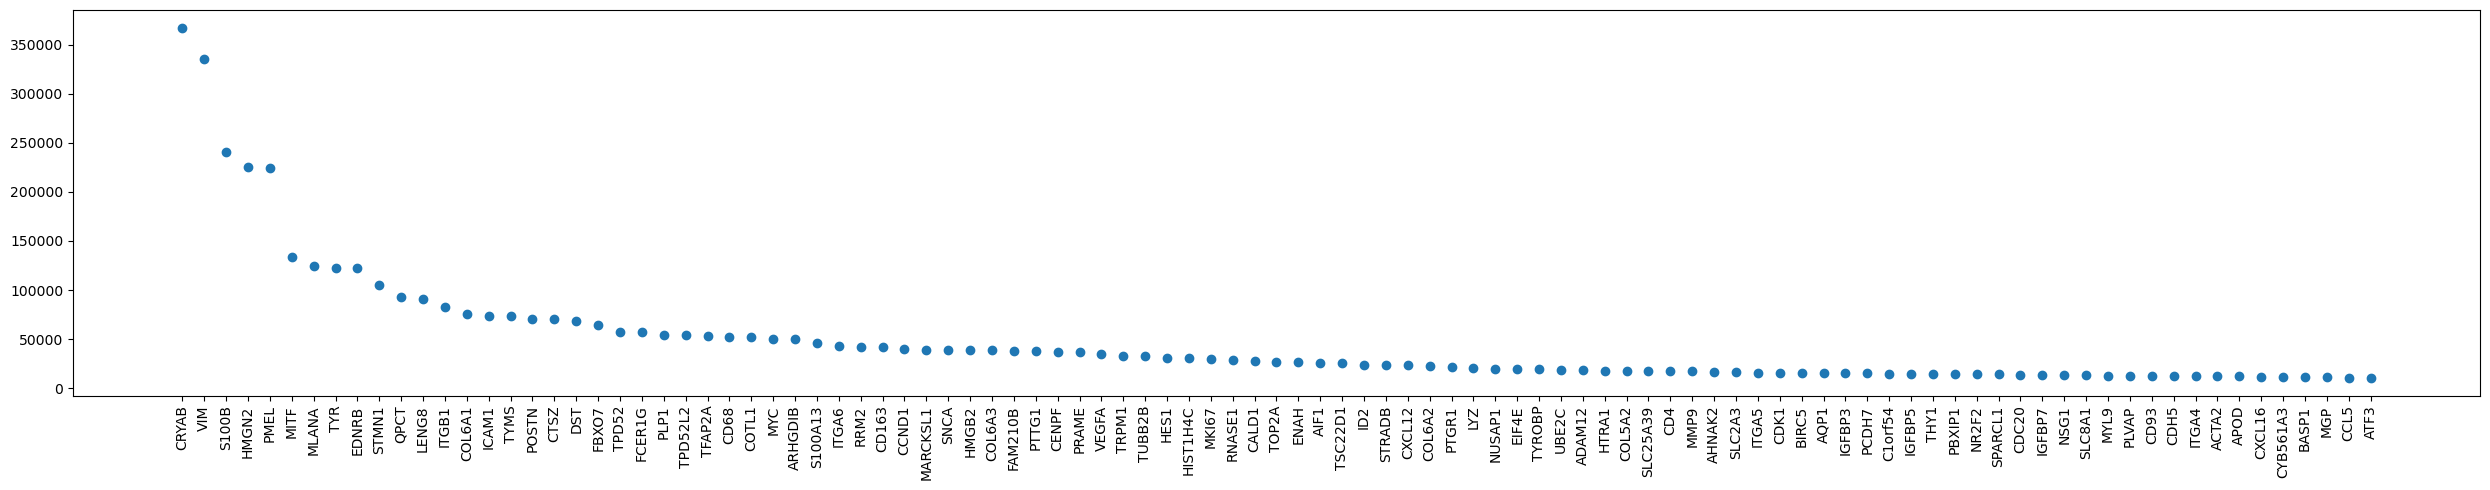

In [33]:
## Plot the top 50 genes
top_genes_object = top_genes_object.iloc[0:101]

plt.figure(figsize=(25, 5))
plt.scatter(top_genes_object['gene'], top_genes_object['total_counts'])
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    os.path.join(qc_path, f"top_50_genes_by_counts_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )

In [34]:
# ## Read in pre-labelled object

#file_path =f"{output_path}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad"
file_path =f"{raw_path}/{dataset_name}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad"

print("Exists?", os.path.exists(file_path))

Exists? True


In [35]:
## Read in the processed AnnData file
#adata_lab = ad.read_h5ad(f"{output_path}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad")
adata_lab = ad.read_h5ad(f"{raw_path}/{dataset_name}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad")
adata_lab.obs_keys()


## Read in the banksy_dict dictionary as a .pkl file
## Use gzip to save it with compression
import gzip
import pickle
#with gzip.open(f"{output_path}/{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz", "rb") as f:
with gzip.open(f"{raw_path}/{dataset_name}/{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz", "rb") as f:
    banksy_dict = pickle.load(f)


## Read in the results_df data frame as a .pkl file
#with gzip.open(f"{output_path}/results_df_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.pkl.gz", "rb") as f:
with gzip.open(f"{raw_path}/{dataset_name}/results_df_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.pkl.gz", "rb") as f:
    results_df = pickle.load(f)

In [36]:
import scipy.sparse as sp
import numpy as np

# Check if values are integers
if sp.issparse(adata.X):
    values = adata.X.data  # non-zero values only
else:
    values = adata.X.flatten()

print(values[:20])  # look at actual values
print(f"Are all integers: {np.all(values == values.astype(int))}")
print(f"Max value: {values.max()}")
print(f"Min value: {values.min()}")

[ 5.  5.  4.  5.  1.  2.  1.  3.  4.  1.  1.  9.  3.  1.  2.  2. 11.  1.
  1.  7.]
Are all integers: True
Max value: 221.0
Min value: 1.0


In [37]:
# Check the ratio
print(adata.obs['nCount_Xenium'].max())        # ~1800 - ALL transcripts
print(np.asarray(adata.X.sum(axis=1)).max())   # ~160  - gene panel only

1892
1892.0


In [38]:
# # #### PCA dimensions

# import scipy.sparse as sp

# if sp.issparse(adata_lab.X):
#     X = adata_lab.X.toarray()
# else:
#     X = np.array(adata_lab.X) 

# ## Import the noise_equiv_singular_value() function 
# from banksy_utils.pca import plot_singular_values
# import numpy as np

# # Transpose the matirx so that the columns are the genes (features) not the cell IDs
# X = X.T
# X.shape

# # Calculate the higher singular value 
# from banksy_utils.pca import noise_equiv_singular_value

# noise_sv, all_permuted_svs = noise_equiv_singular_value(
#     data = X,
#     num_permutations = 50,
#     #average_type = "mean",
#     verbose = True
#     )
# print(f"Noise threshold (mean top singular value of permuted data): {noise_sv:.4f}")

In [39]:

# ## Perform PCA 
# from sklearn.decomposition import PCA

# pca = PCA(n_components=50).fit(X)


# ## Plot singular values vs noise to determine the optimal number of PC above the noise threshold
# from banksy_utils.pca import plot_singular_values

# plot_singular_values(
#     pca, 
#     noise_highest_sv=noise_sv, 
#     title=f"Singular values vs noise_{dataset_name}",
#     figsize=(20,20),
#     #save_path = f"{output_path}singular_values_vs_noise_{dataset_name}"
#     )

# plt.xlabel("Number of principal components", fontsize=20)
# plt.ylabel("Number of singular values", fontsize=20)

# plt.savefig(
#     os.path.join(qc_path, f"singular_values_vs_noise_{dataset_name}.png"),
#     dpi=300,
#     bbox_inches='tight'
#     )

In [40]:
# ## Display previously generated UMAP plots

# Identify the largest label number and set that to max_num_labels

## extract the seperate spatial and non-spatial results
nonspatial_results = results_df[results_df["decay"] == "nonspatial"]
spatial_results = results_df[results_df["decay"] == "scaled_gaussian"]

nonspatial_labels = nonspatial_results["num_labels"].max()
spatial_labels = spatial_results["num_labels"].max()

def determine_max_num_labels(nonspatial_labels, spatial_labels):
## extract the number of labels 

    if nonspatial_labels > spatial_labels:
        max_num_labels = nonspatial_labels
        print(f"The number of nonspatial labels {nonspatial_labels} is greater than spatial labels {spatial_labels}, so {nonspatial_labels} is assigned to max_num_labels which {max_num_labels}.")

    if nonspatial_labels < spatial_labels:
        max_num_labels = spatial_labels
        print(f"The number of spatial labels {nonspatial_labels} is greater than nonspatial labels {spatial_labels}, so {spatial_labels} is assigned to max_num_labels which {max_num_labels}.")

    elif nonspatial_labels == spatial_labels:
        print(f"nonspatial and spatial decay have generated the same number of clusters, so {nonspatial_labels} is assigned to max_num_labels which is {max_num_labels}.")

    return(max_num_labels)


max_num_labels=determine_max_num_labels(nonspatial_labels, spatial_labels)

The number of nonspatial labels 11 is greater than spatial labels 10, so 11 is assigned to max_num_labels which 11.


Saving figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_nonspatial_pc35_nc0.00_r0.50_spatialmap.png
number of labels: 11
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 11
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 11
---- Ran plot_2d_embeddings in 0.00 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((11, 30203) x (30203, 30203) x (30203, 11))

Saving full-figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_nonspatial_pc35_nc0.00_r0.50_full_figure.png
Saving figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_scaled_gaussian_pc35_nc0.20_r0.50_spatialmap.png
number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((1

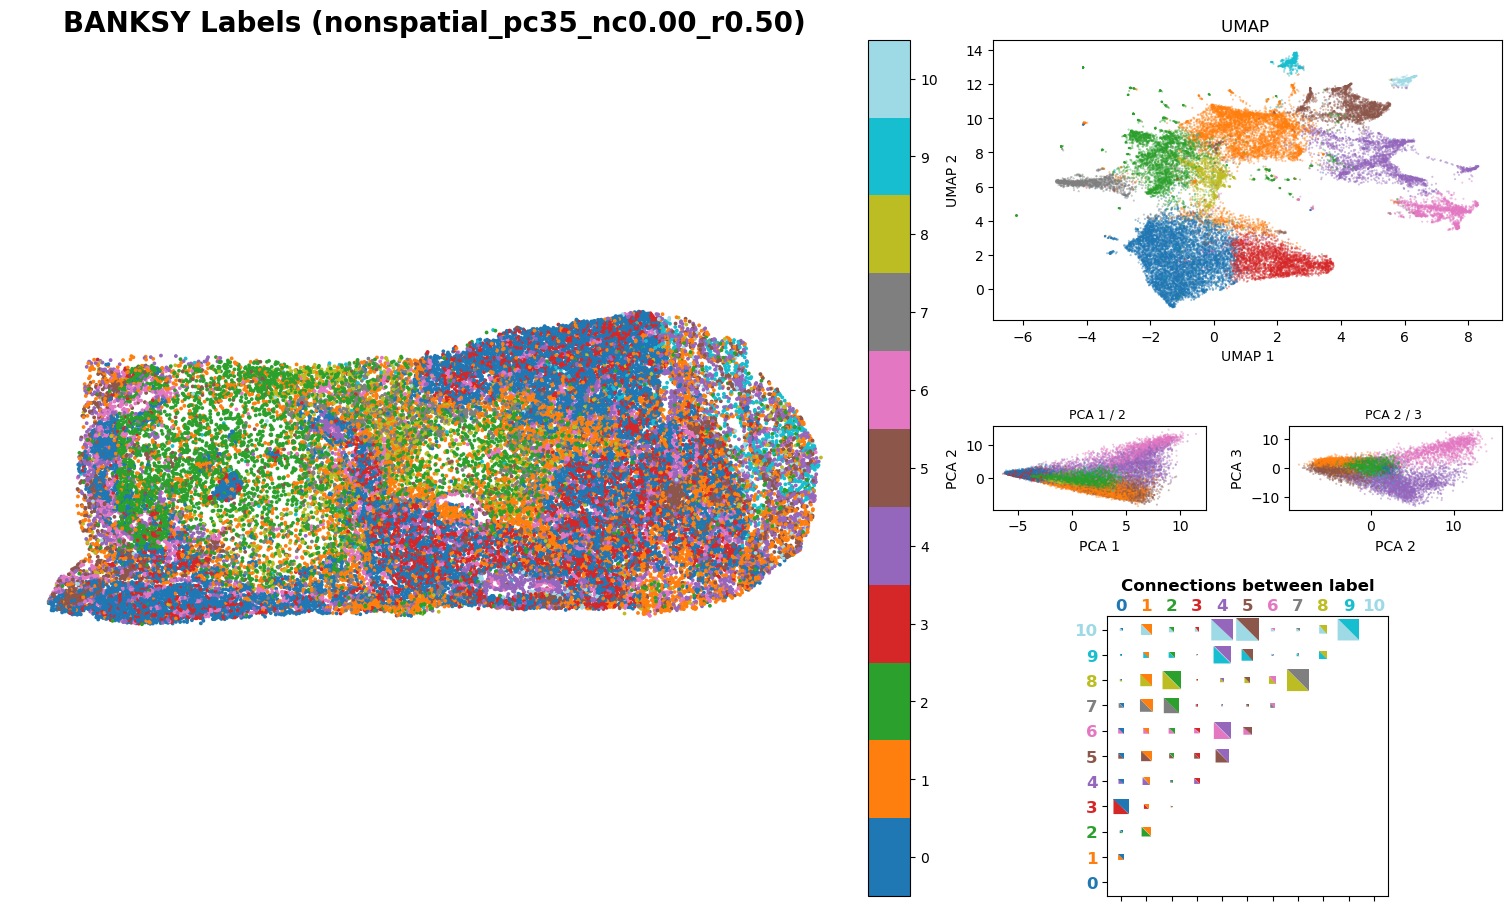

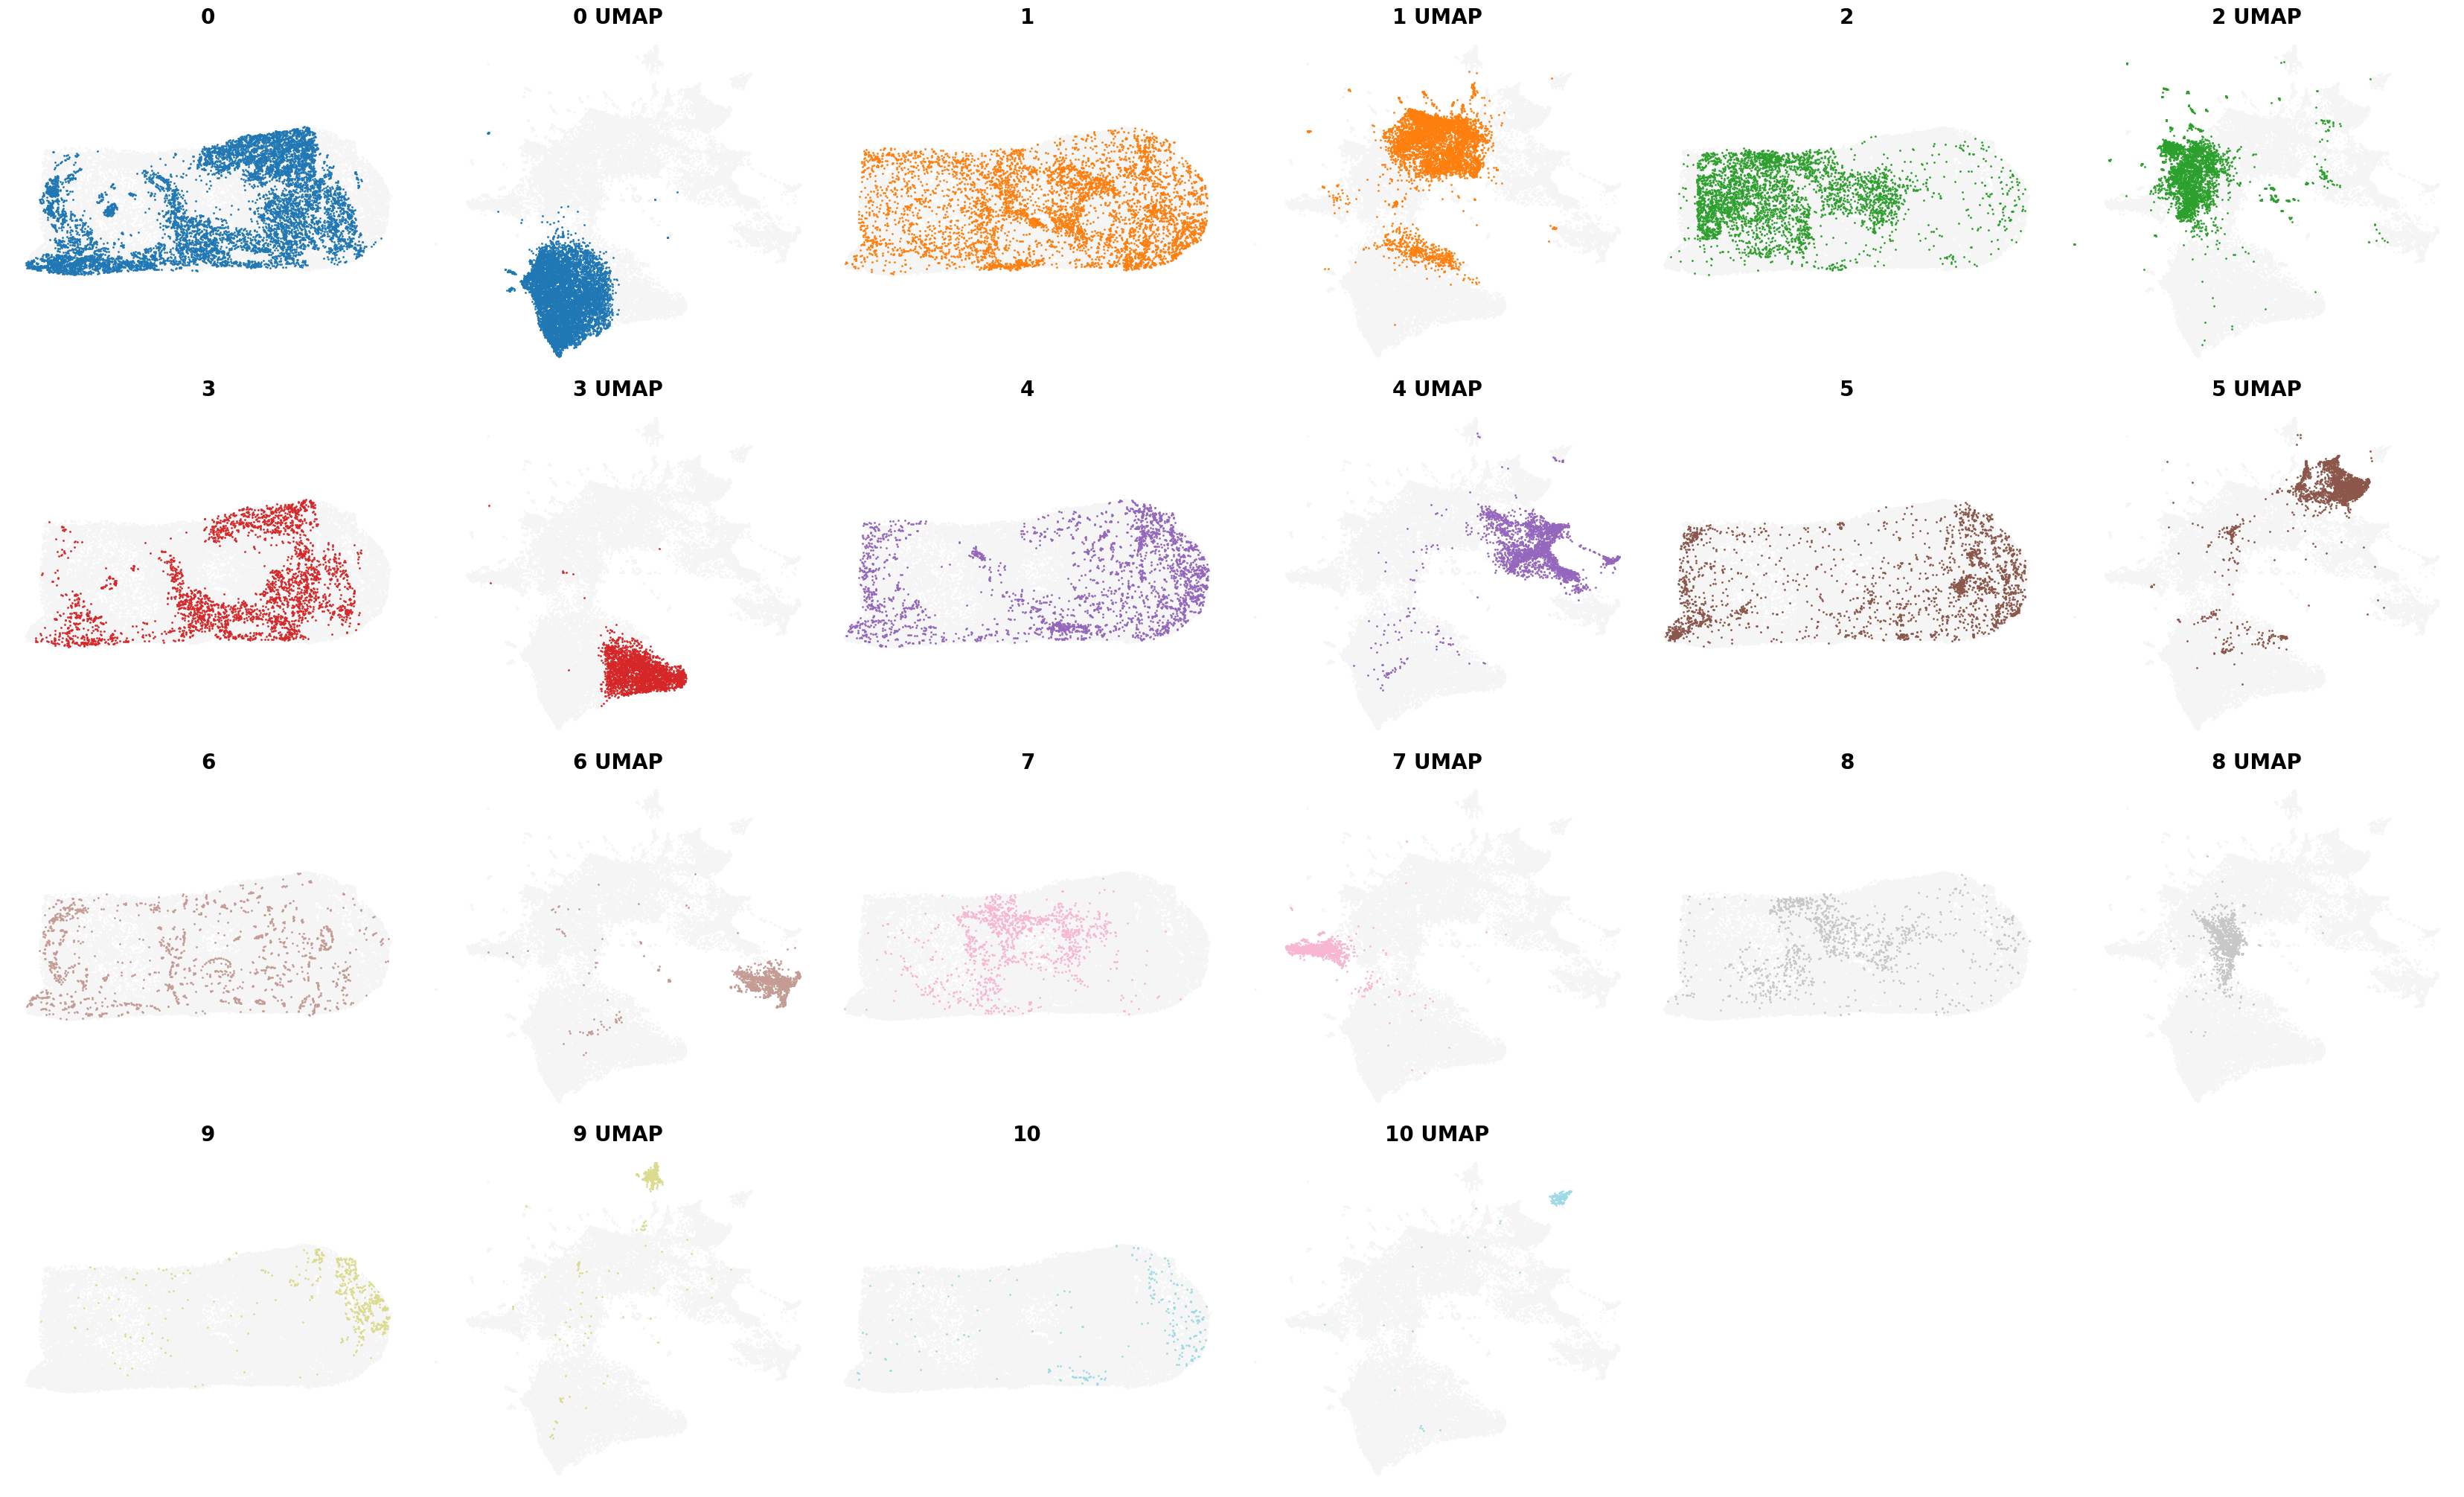

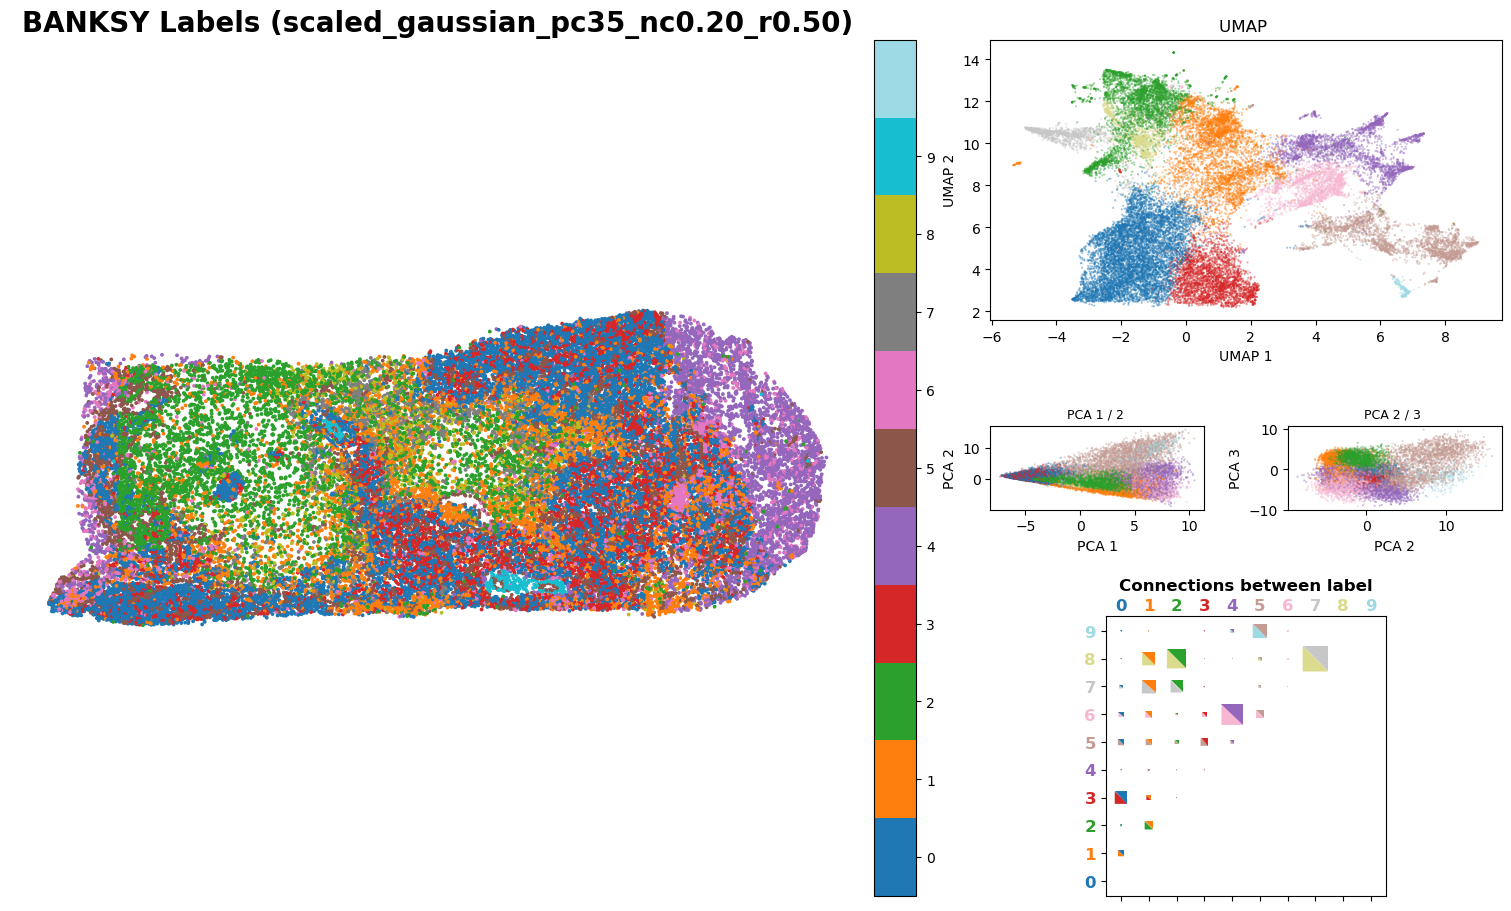

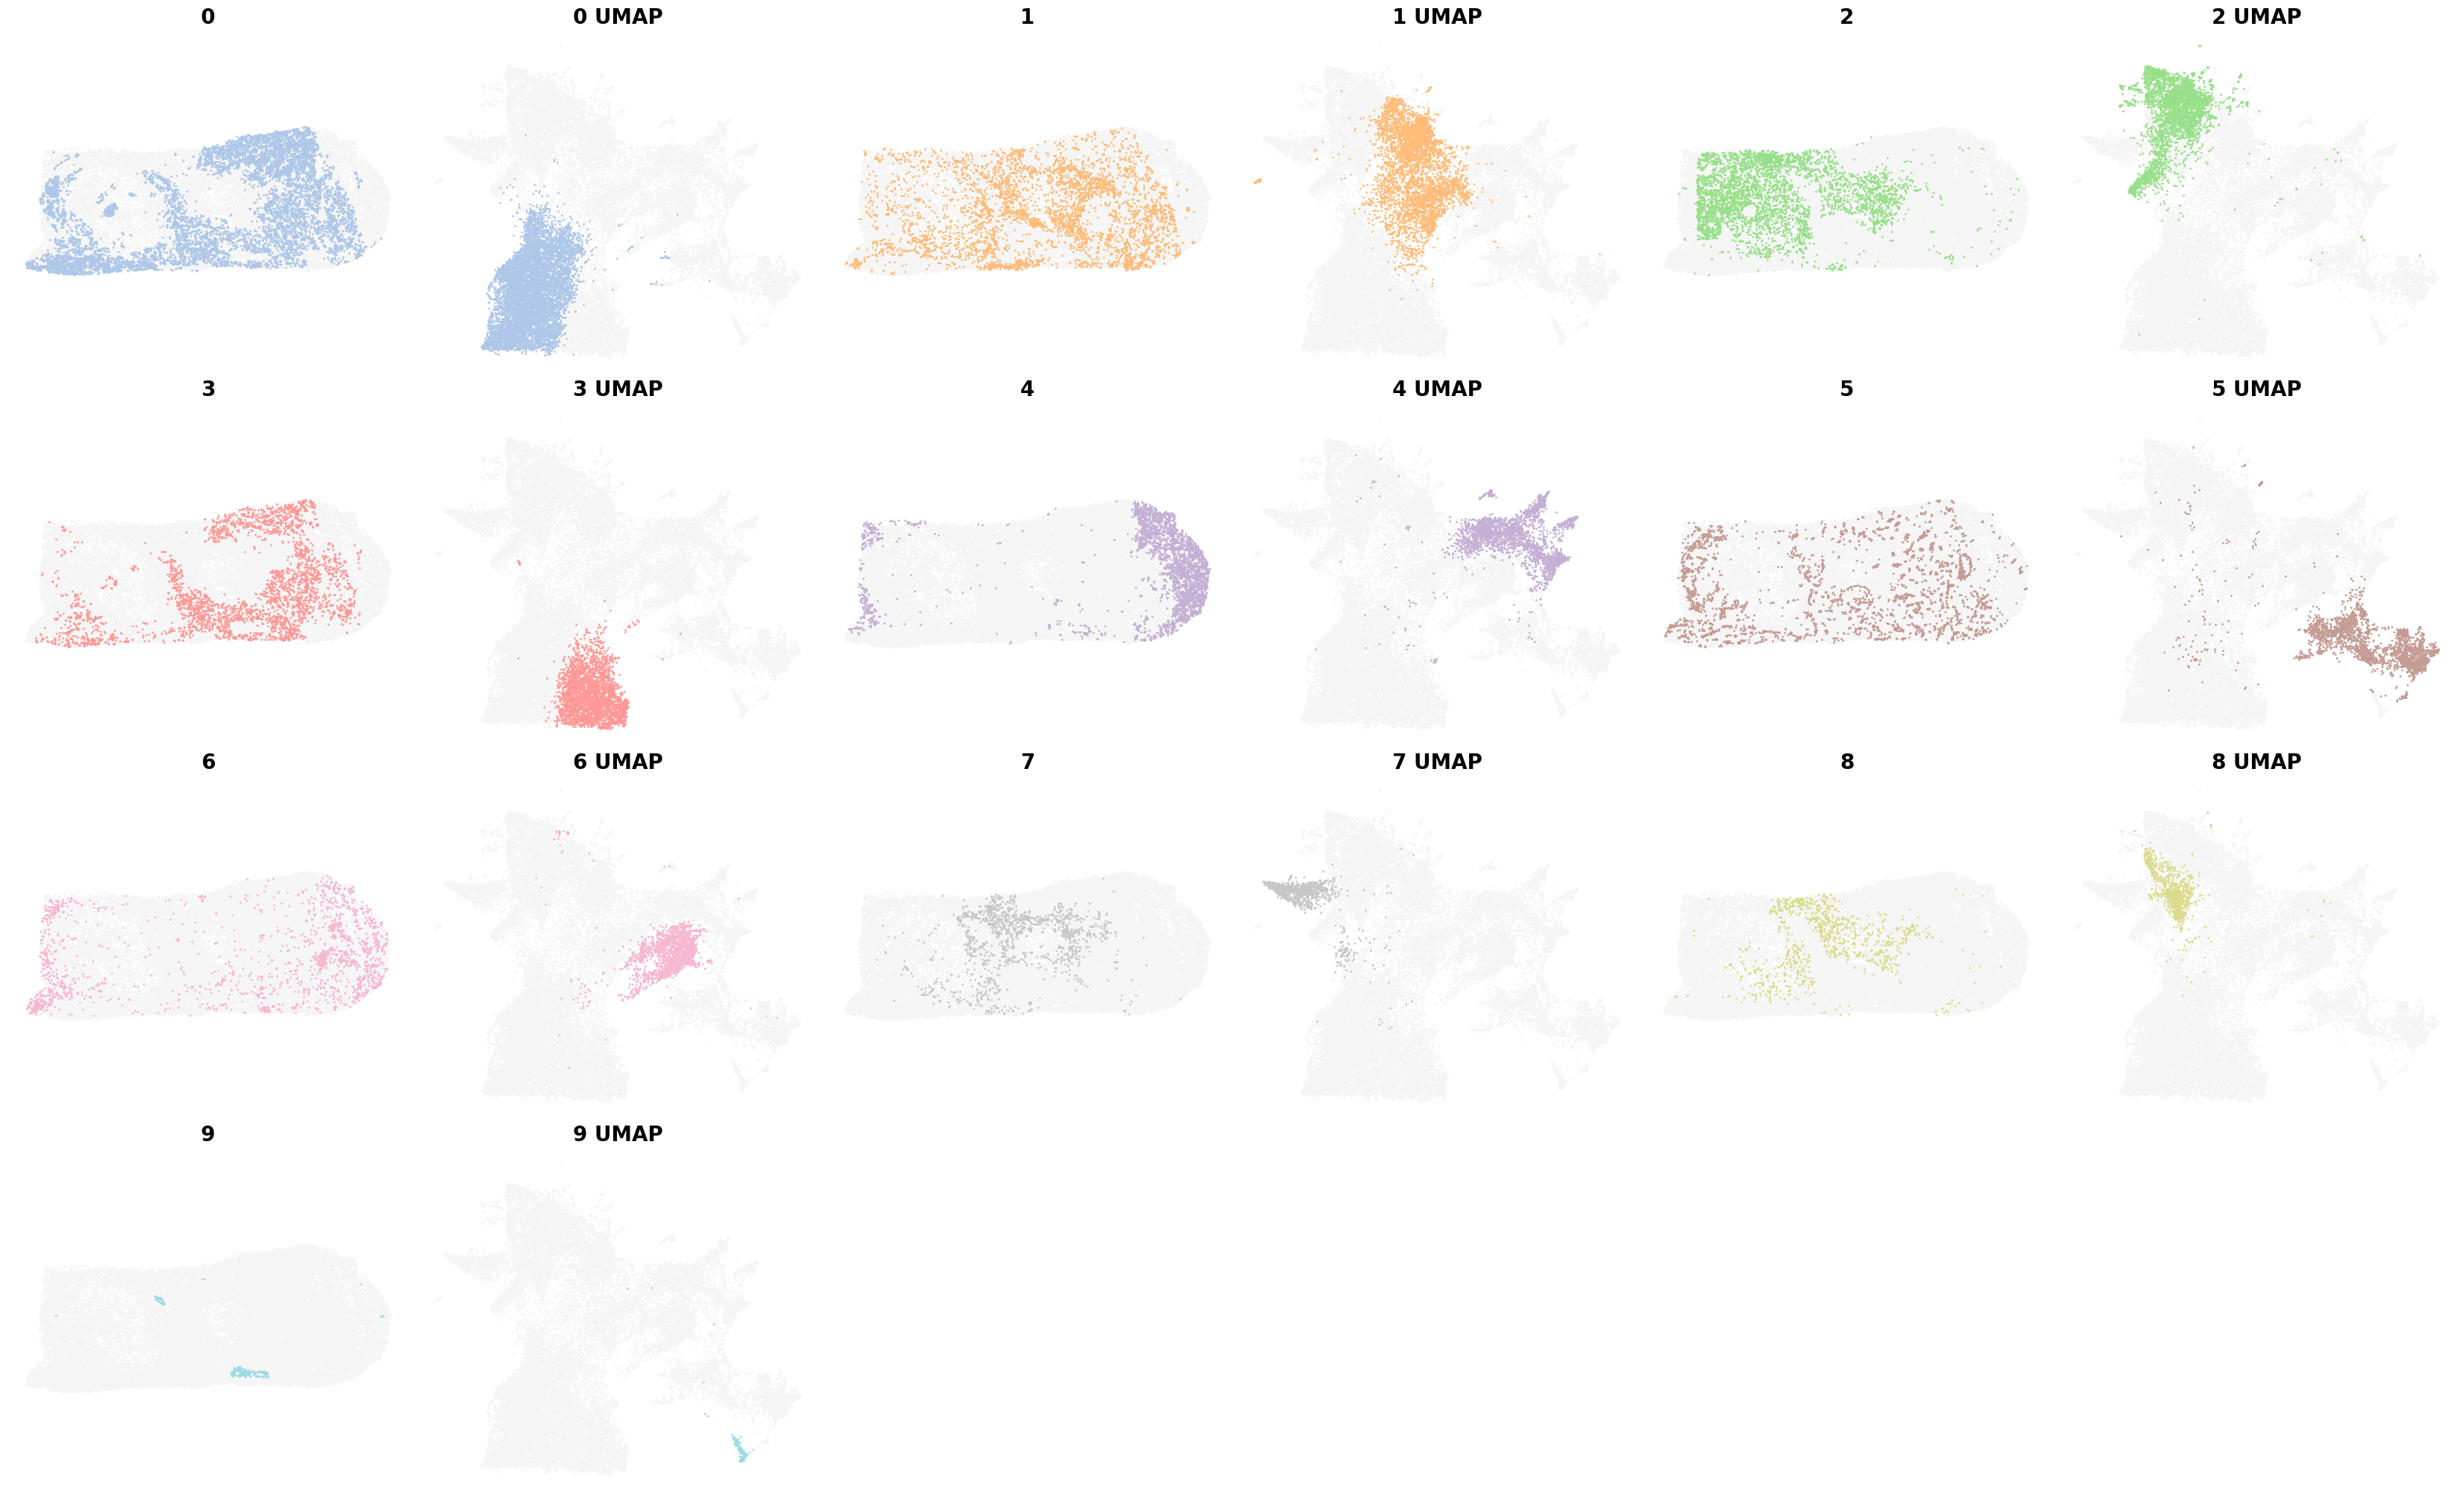

In [41]:
from banksy.plot_banksy import plot_results

c_map =  'tab20' # specify color map
weights_graph =  banksy_dict[f"{nbr_weight_decay}"]['weights'][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels = False,
    coord_keys = coord_keys,
    max_num_labels  =  max_num_labels, 
    #save_path = os.path.join(file_path, 'tmp_png'),
    save_fig = True, # save the spatial map of all clusters
    save_seperate_fig = True, # save the figure of all clusters plotted seperately
    dataset_name = f"{dataset_name}",
    save_fullfig=True,
    save_path = output_path
)

In [42]:
## Generate place holder labels for clusters
from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata

## Spatial cluster place holders
cluster2annotation_spatial = {}

for i in range(spatial_labels):
    cluster2annotation_spatial[str(i)] = str(i)
print(cluster2annotation_spatial)

## Non-spatial cluster place holders
cluster2annotation_nonspatial = {}

for i in range(nonspatial_labels):
    cluster2annotation_nonspatial[str(i)] = str(i)
print(cluster2annotation_nonspatial)

pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

{'0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9'}
{'0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9', '10': '10'}


In [43]:
## Save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
                                    pca_dims,
                                    lambda_list, 
                                    resolutions,
                                    cluster2annotation_spatial,
                                    cluster2annotation_nonspatial)

Using spatial params: scaled_gaussian_pc35_nc0.20_r0.50
nonspatial_pc35_nc0.00_r0.50


In [44]:
## Store the cluster labels as a string in .obs
banksy_dict[f"{nbr_weight_decay}"][0.2]['adata'] #lambda = 0.20
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"]= adata_spatial.obs[f"labels_scaled_gaussian_pc{pca_label}_nc{lambda_label}_r{res_label}"].astype(str)

In [45]:
## The top 20 gene markers for each cluster are assessed for cell cluster annotation

new_labels = {
    '0' : 'Invasive_Neural_crest-like_melanoma_0',
    '1' : 'M2-like_Tumour_Associated_Macrophages_1',
    '2' : 'Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2',
    '3' : 'Cycling_melanoma_cells_3',
    '4' : 'Cancer_Associated_Fibroblasts_4',
    '5' : 'Vascular_Endothelial_Cells_5', 
    '6' : 'Cytotoxic_CD8+_and_CD4+_T_Cells_6',
    '7' : 'Immature_Myeloid_Cells_or_Tumour_Myeloid_Cells_7',
    '8' : 'Mesenchymal-like_Melanoma_Cells_8',
    '9' : 'Vascular_smooth_muscle_or_pericytes_9'
}

# cluster_col = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs["cell type"].map(new_labels)

new_labels


# #### Cluster level violin plot of cells that pass the minimum trancript count threshhold "threshold_passed_str"

{'0': 'Invasive_Neural_crest-like_melanoma_0',
 '1': 'M2-like_Tumour_Associated_Macrophages_1',
 '2': 'Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2',
 '3': 'Cycling_melanoma_cells_3',
 '4': 'Cancer_Associated_Fibroblasts_4',
 '5': 'Vascular_Endothelial_Cells_5',
 '6': 'Cytotoxic_CD8+_and_CD4+_T_Cells_6',
 '7': 'Immature_Myeloid_Cells_or_Tumour_Myeloid_Cells_7',
 '8': 'Mesenchymal-like_Melanoma_Cells_8',
 '9': 'Vascular_smooth_muscle_or_pericytes_9'}

In [46]:
## Transfer the minimum threshold values from the adata.obs to the adata_spatial.obs
adata_spatial.obs['threshold_passed'] = adata.obs['threshold_passed']
## Transfer the minimum threshold category labels from the adata.obs to the adata_spatial.obs
adata_spatial.obs['threshold_passed_cat'] = adata.obs['threshold_passed_cat']

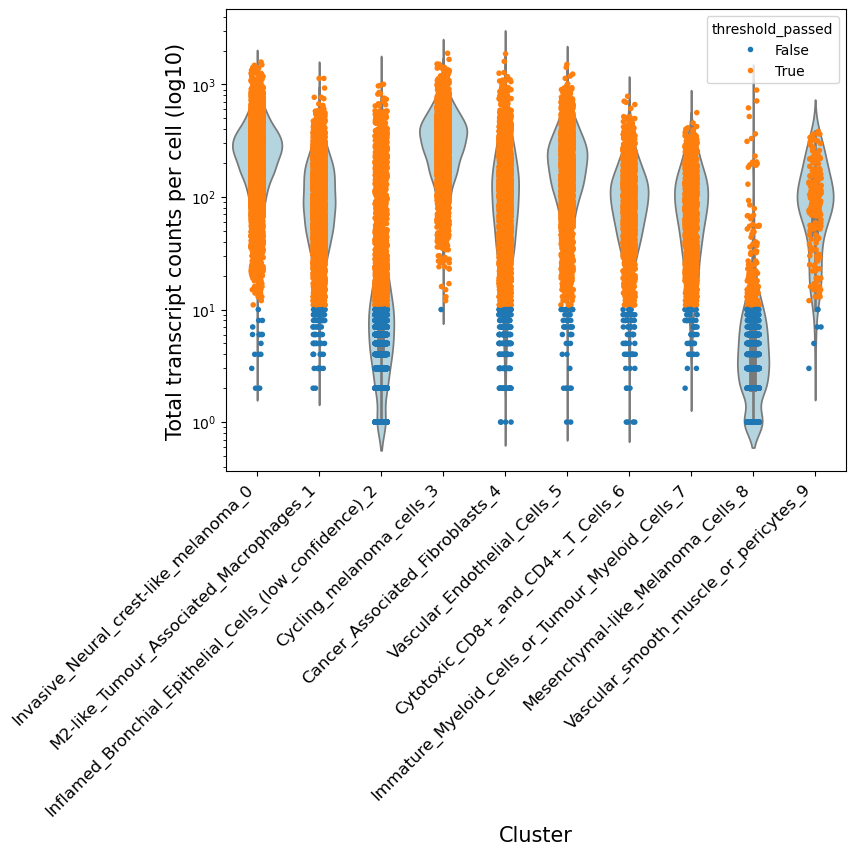

In [47]:
obs = adata_spatial.obs
cell_label = "banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"

plt.figure(figsize=(8, 6))
sns.violinplot(data=obs, y=obs["nCount_Xenium"],  x=obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"], log_scale=10, color="lightblue")

sns.stripplot(data=obs, y=obs["nCount_Xenium"], x=obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"], hue =obs["threshold_passed"], size=4)

plt.xlabel("Cluster", fontsize=15)
plt.ylabel("Total transcript counts per cell (log10)", fontsize=15)
plt.xticks(rotation=45, fontsize=12, ha='right', va='top')


plt.savefig(
    os.path.join(qc_path, f"threshold_passed_cells_per_cluster_violin_plot_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )



In [48]:
# # Top expressed genes per cluster
# ### Spatial clustering results

import scanpy as sc

## Rank genes and identify cluster gene markers
sc.tl.rank_genes_groups(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
    method='wilcoxon',
    key_added=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"
)

In [49]:
## Check which cluster keys exist
adata_spatial.uns[f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers']['names'].dtype

dtype((numpy.record, [('0', 'O'), ('1', 'O'), ('2', 'O'), ('3', 'O'), ('4', 'O'), ('5', 'O'), ('6', 'O'), ('7', 'O'), ('8', 'O'), ('9', 'O')]))

In [50]:
## Using the filter_ranked_genes_by_type to create a key for 
from banksy_utils.annotation_utils import filter_ranked_genes_by_type

key_filtered = filter_ranked_genes_by_type(
    adata_spatial,
    key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers",
    top_n=100,
    gene_type = "raw",
    new_key_suffix="_raw",
)

Copied cluster labels to adata.obs['banksy_cluster_pc35_nc0.20_r0.50_raw']
Stored filtered raw markers in adata.uns['banksy_cluster_pc35_nc0.20_r0.50_markers_raw']


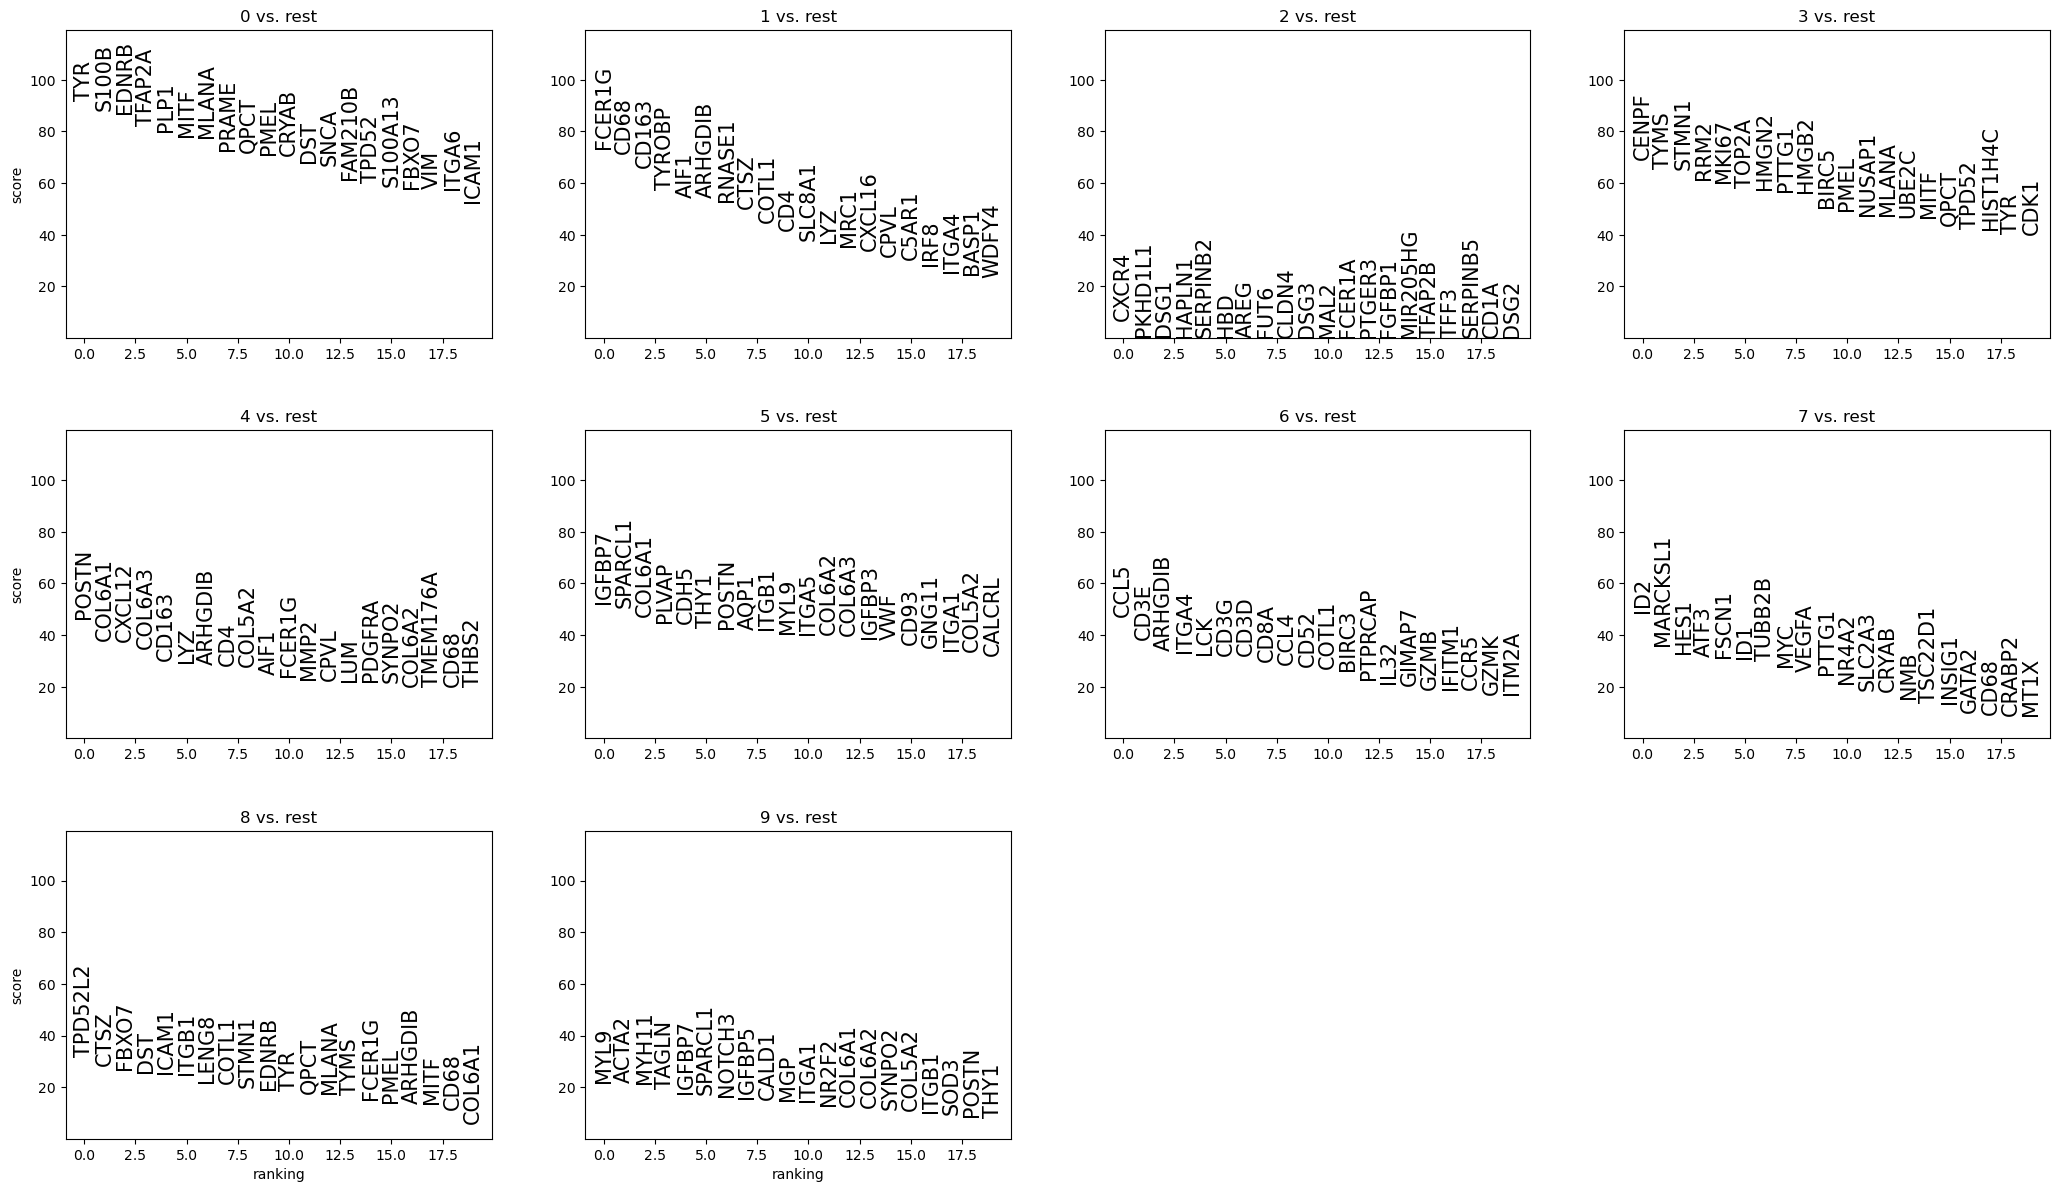

In [51]:
# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_spatial, 
    key=key_filtered,
    method='wilcoxon',
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_0", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_1", 
    #key_added = 'banksy_cluster_pc35_nc0.20_r0.50_markers_raw',
    #key_added= "raw_test",
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_raw.png")

In [52]:
# # Plot the gene markers for each cluster as a violin plot that conpares to every other cluster
# with rc_context({"figure.figsize": (9, 1.5)}):
#     sc.pl.rank_genes_groups_violin(
#         adata_spatial, 
#         n_genes=20, 
#         jitter=False, 
#         key = key_filtered
#         )

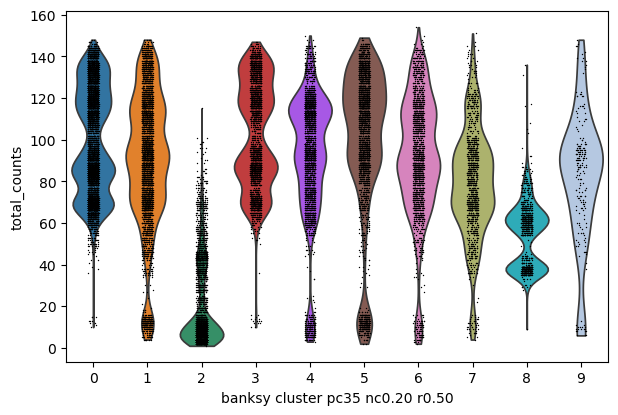

In [53]:
sc.pl.violin(
    adata_spatial, 
    "total_counts", 
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}", 
    save= f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
    )

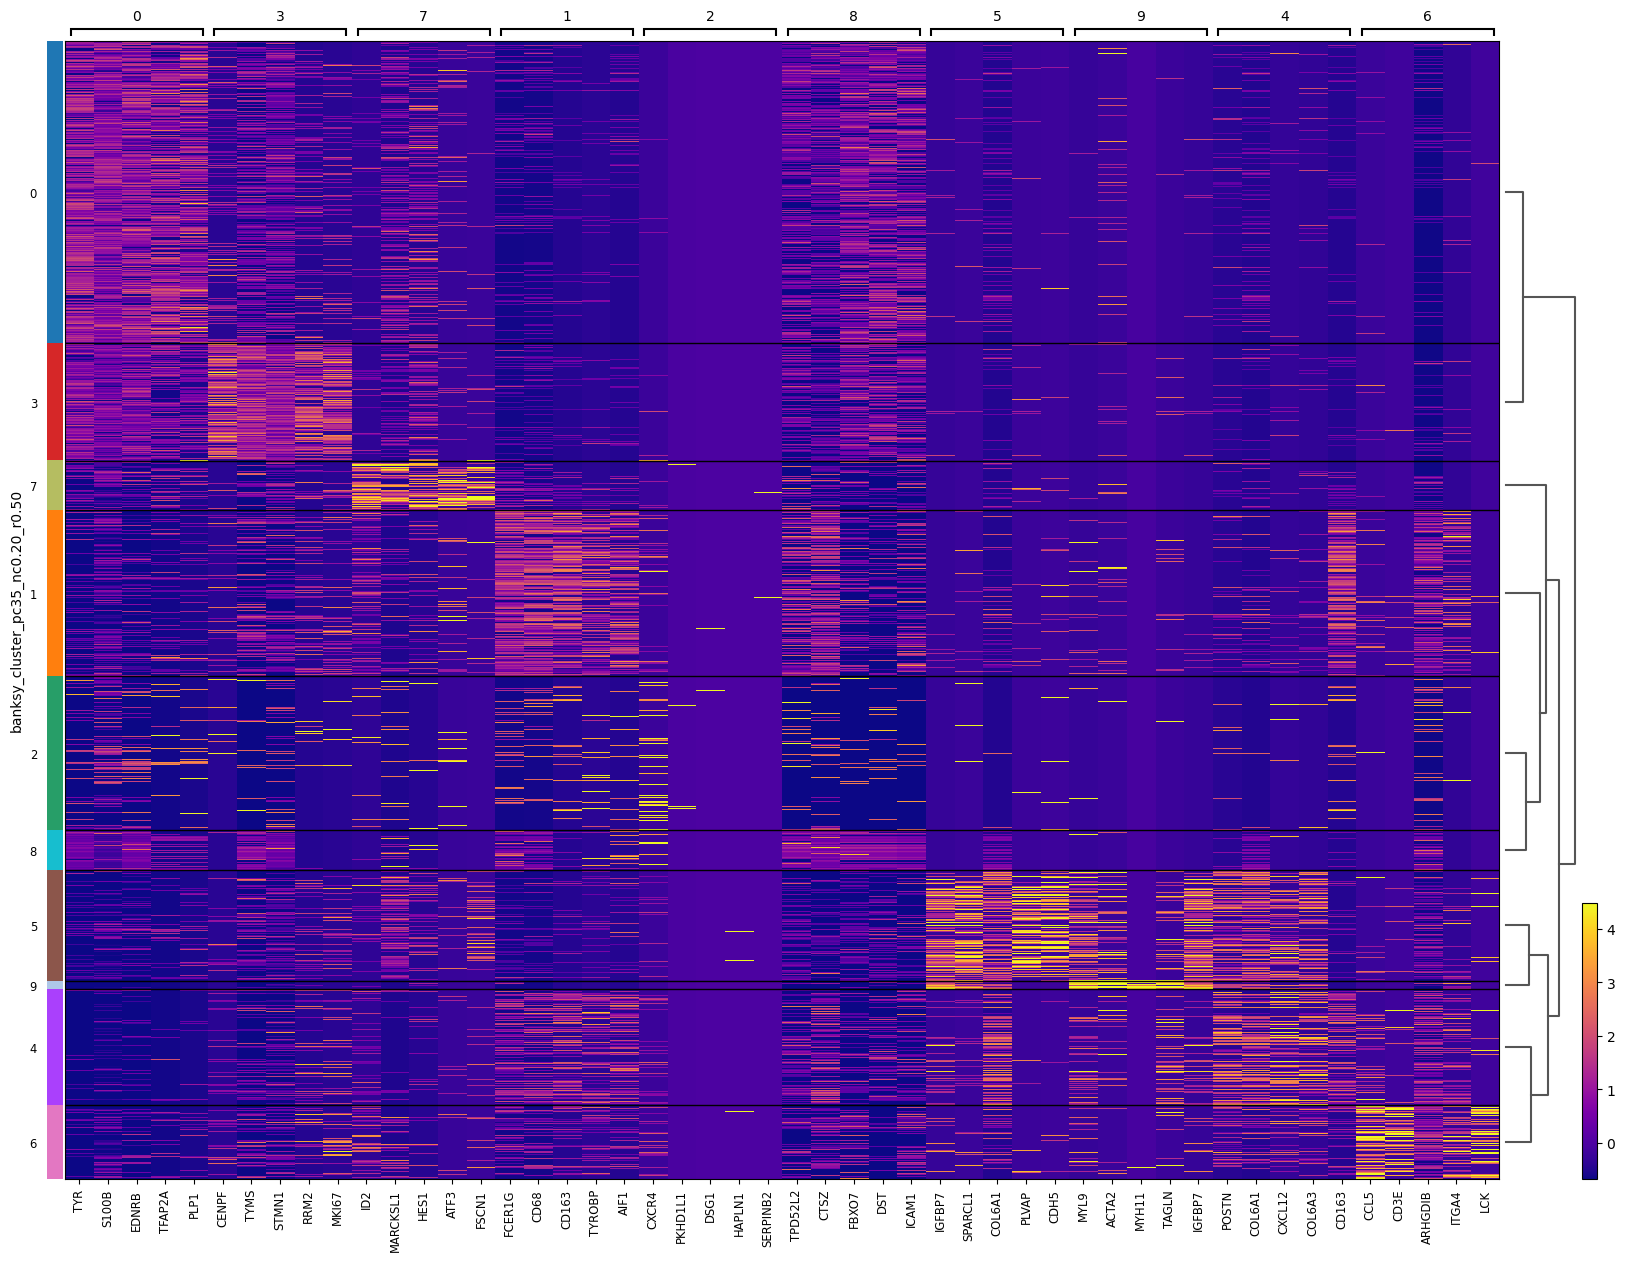

In [54]:
# Set the figure directory to your desired location
sc.settings.figdir = output_path

## Generate heat map for top markers per cluster
sc.tl.dendrogram(
    adata_spatial,
    groupby=f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_raw',
    key_added=f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_raw'
)

## Determine vmin and vmax dynamically based on gene expression
expr_values = adata_spatial.X
vmax_dynamic = np.percentile(expr_values[expr_values > 0], 99)
vmin_dynamic = np.percentile(expr_values, 1)

sc.pl.rank_genes_groups_heatmap(
    adata_spatial, 
    key=f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw',
    #key= 'raw_test',
    n_genes=5,
    cmap = "plasma",
    vmin=vmin_dynamic,
    vmax=vmax_dynamic,
    show_gene_labels = True,
    save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_raw_markers.png",
    figsize=(20, 15)
)

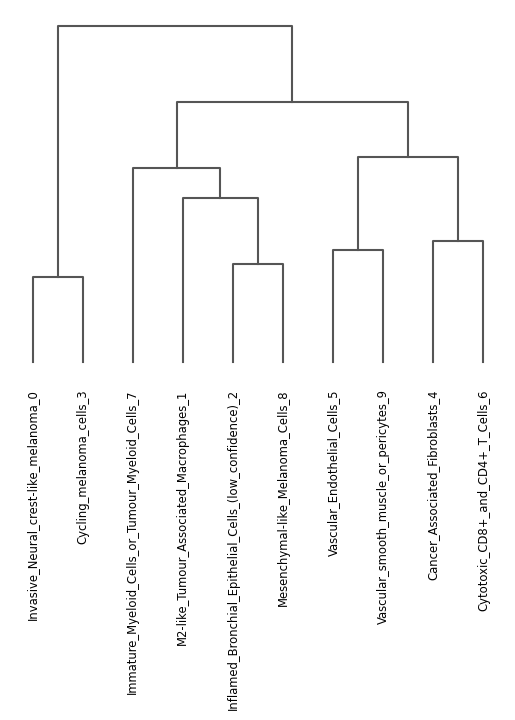

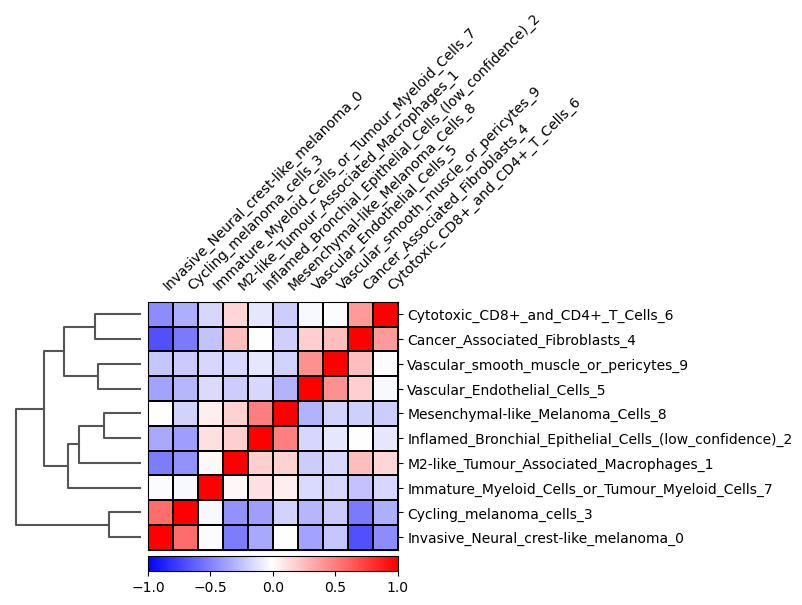

In [55]:

groupby_key = f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann'

sc.tl.dendrogram(adata_spatial, groupby=groupby_key)

sc.pl.dendrogram(
    adata_spatial,
    groupby=groupby_key,
    save=f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
)

sc.pl.correlation_matrix(
    adata_spatial,
    groupby = groupby_key,
    save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_cluster_correlation_plot.png",
    figsize=(5, 3.5)
)

In [56]:
# ### Export the top 20 clusters in wide format to .csv

from banksy_utils.annotation_utils import export_clusters_wide

key= f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw"

export_clusters_wide(
    adata= adata_spatial,
    key= key,
    gene_type= "raw",
    top_n= 20,
    dataset_name= dataset_name,
    file_path= processed_path
)

          0        1         2         3         4        5        6  \
0       TYR   FCER1G     CXCR4     CENPF     POSTN   IGFBP7     CCL5   
1     S100B     CD68   PKHD1L1      TYMS    COL6A1  SPARCL1     CD3E   
2     EDNRB    CD163      DSG1     STMN1    CXCL12   COL6A1  ARHGDIB   
3    TFAP2A   TYROBP    HAPLN1      RRM2    COL6A3    PLVAP    ITGA4   
4      PLP1     AIF1  SERPINB2     MKI67     CD163     CDH5      LCK   
5      MITF  ARHGDIB       HBD     TOP2A       LYZ     THY1     CD3G   
6     MLANA   RNASE1      AREG     HMGN2   ARHGDIB    POSTN     CD3D   
7     PRAME     CTSZ      FUT6     PTTG1       CD4     AQP1     CD8A   
8      QPCT    COTL1     CLDN4     HMGB2    COL5A2    ITGB1     CCL4   
9      PMEL      CD4      DSG3     BIRC5      AIF1     MYL9     CD52   
10    CRYAB   SLC8A1      MAL2      PMEL    FCER1G    ITGA5    COTL1   
11      DST      LYZ    FCER1A    NUSAP1      MMP2   COL6A2    BIRC3   
12     SNCA     MRC1    PTGER3     MLANA      CPVL   COL6A3  PTP

In [57]:
# ### Export the top 20 clusters in long format with scores to .csv

from banksy_utils.annotation_utils import export_cluster_markers

export_cluster_markers(
    adata = adata_spatial,
    key = key,
    top_n = 20,
    dataset_name = dataset_name,
    file_path = processed_path
)

Saved to data/xenium/processed/GR_lung_non_res_roi


,cluster,gene,score
0,0,TYR,91.757233
1,0,S100B,88.008461
2,0,EDNRB,86.976738
3,0,TFAP2A,82.414078
4,0,PLP1,79.724991
...,...,...,...
195,9,COL5A2,10.978094
196,9,ITGB1,10.121636
197,9,SOD3,9.216952
198,9,POSTN,8.504077


'data/xenium/processed/GR_lung_non_res_roi'

In [ ]:
# ### Add cell_type information to top clusters for manual annotation

## Read in the exported cluster markers generated with "export_clusters_wide()"
## and merge with the cell type annotation master document
n_genes_label =  20 # Set this to the number of genes that were exorted as top markers for each cluster
top_markers = pd.read_csv(f"{processed_path}/cluster_top_{n_genes_label}_genes_with_scores_{dataset_name}_{key}.csv", index_col=0) #index_col = 0 prevents insertion of an unnamed col
top_markers = top_markers.sort_values(by='cluster', ascending=False)
#print(top_markers)

## Read in the master annotation file which contains all the curated cell type labels for each marker gene
#master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master.csv")
master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master_v1_March_2026_Tier1.csv")

## Create a data frame of the genes and their corresponding primary and secondary cell type annotations 
cell_annotations = master_markers_file[["Gene", "primary_annotation", "secondary_annotation"]]
#cell_annotations = cell_annotations.sort_index()

# ## Merge the top marker results and the cell type annotations
# merged_markers = (
#     pd.merge(
#         #top_markers.reset_index(),
#         top_markers.sort_values(by='cluster', ascending=False),
#         cell_annotations, 
#         left_on="gene", 
#         right_on="Gene", 
#         how="left", 
#         sort="False",
#         #validate="m:1"
#     )
#     #.set_index("index")
#     #.loc[top_markers.index]
# )

merged_markers = top_markers.reset_index().merge(
    cell_annotations,
    left_on="gene",
    right_on="Gene",
    how='left'
)
merged_markers['cluster'] = merged_markers['cluster'].astype(int)
merged_markers = merged_markers.sort_values('cluster', ascending=True).reset_index(drop=True)
merged_markers = merged_markers.drop("Gene", axis=1)
print(merged_markers)

## Export the cell type annotated top markers to .csv to use in manual annotation and ChatGPT annotation
merged_markers.to_csv(f"{processed_path}/cell_type_cluster_top_{n_genes_label}_genes_{dataset_name}_{key}.csv")

     cluster     gene      score  \
0          0      TYR  91.757233   
1          0     MITF  78.008942   
2          0     QPCT  71.803452   
3          0    PRAME  72.726631   
4          0    MLANA  77.701904   
..       ...      ...        ...   
195        9   SYNPO2  11.377514   
196        9   COL6A2  12.107780   
197        9   COL6A1  12.420733   
198        9  SPARCL1  17.313755   
199        9     THY1   8.082713   

                                primary_annotation  \
0                            Melanocytes; Melanoma   
1                                         Melanoma   
2                                      Melanocytes   
3                                              NaN   
4                                      Melanocytes   
..                                             ...   
195                            DC_CLEC9A_migrating   
196   Fibroblasts; Secretory-papillary Fibroblasts   
197   Fibroblasts; Secretory-papillary Fibroblasts   
198  Endothelial cells; Vas

In [66]:
cell_annotations

,Gene,primary_annotation,secondary_annotation
0,CD79A,B cells,NaN
1,LTB,DC_AXL_SIGLEC6; T regulatory cells; T Cells,NaN
2,MEF2C,B cells,NaN
3,MZB1,B cells; Erythrocytes,NaN
4,PKHD1L1,B cells,NaN
...,...,...,...
299,VWF,Endothelial cells; Vascular Endothelial Cells,NaN
300,SELL,NaN,T_cells; T_cell_naive; vascular_endothelial_cells
301,SELP,NaN,vascular_endothelial_cells
302,VCAM1,NaN,endothelial_cells


In [69]:
top_markers

,gene,score
cluster,,
9,THY1,8.082713
9,MGP,14.824059
9,MYL9,21.786688
9,ACTA2,21.673132
9,MYH11,21.267111
...,...,...
0,FBXO7,57.738300
0,VIM,57.666168
0,ITGA6,57.553116


In [ ]:
## The top 20 gene markers for each cluster are assessed for cell cluster annotation

new_labels = {
    '0' : 'Invasive_Neural_crest-like_melanoma_0',
    '1' : 'M2-like_Tumour_Associated_Macrophages_1',
    '2' : 'Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2',
    '3' : 'Cycling_melanoma_cells_3',
    '4' : 'Cancer_Associated_Fibroblasts_4',
    '5' : 'Vascular_Endothelial_Cells_5', 
    '6' : 'Cytotoxic_CD8+_and_CD4+_T_Cells_6',
    '7' : 'Immature_Myeloid_Cells_or_Tumour_Myeloid_Cells_7',
    '8' : 'Mesenchymal-like_Melanoma_Cells_8',
    '9' : 'Vascular_smooth_muscle_or_pericytes_9'
}

cluster_col = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs["cell type"].map(new_labels)

new_labels

In [ ]:
## Store the UMAP results in the .obsm slot
adata_spatial.obsm['X_umap'] = banksy_dict['scaled_gaussian'][0.2]['adata'].obsm[f"reduced_pc_{pca_label}_umap"]


# ## Visualisations

# ### Cluster Annotated UMAP

In [ ]:
# Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
]

with rc_context({"figure.figsize": (3,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=50, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
        )

In [ ]:
# Plot the umap with bulk labels

color_vars = [
f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
]

fig, axes = plt.subplots(1, 2, figsize=(20,10))

#with rc_context({"figure.figsize": (3,3)}):
sc.pl.umap(
    adata_spatial, 
    color=color_vars, 
    s=5, 
    frameon=True, 
    vmax="p99",
    add_outline=True,
    legend_fontsize=10,
    title=f"{dataset_name} clusters",
    ax=axes[0],
    show=False
    #save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png",
    )
plt.legend(fontsize=20, title_fontsize=50)

color_vars = [
"threshold_passed_cat"
]

#with rc_context({"figure.figsize": (3,3)}):
sc.pl.umap(
    adata_spatial, 
    color=color_vars, 
    s=5, 
    frameon=True, 
    vmax="p99",
    add_outline=True,
    legend_fontsize=10,
    title=f"{dataset_name} clusters",
    ax=axes[1],
    show=False
    #save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png",
    )

plt.tight_layout()
plt.legend(fontsize=20, title_fontsize=50)
plt.savefig(os.path.join(qc_path, f"umap_{dataset_name}_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ### Gene of interest UMAP and violin plotting

## Create a path for gene of interest UMAP plots
umap_path = os.path.join(base_dir,f"output/{dataset_name}/umap/")

if not os.path.isdir(umap_path):
    os.makedirs(umap_path)
    print(f"Directory '{umap_path}' created successfully.")
    
else:
    print(f"Directory '{umap_path}' already exists.")


## Create a path for gene of interest violin plots
violin_path = os.path.join(base_dir,f"output/{dataset_name}/violin/")

if not os.path.isdir(violin_path):
    os.makedirs(violin_path)
    print(f"Directory '{violin_path}' created successfully.")
    
else:
    print(f"Directory '{violin_path}' already exists.")

## Create a path for gene of interest violin plots
dotplot_path = os.path.join(base_dir,f"output/{dataset_name}/dotplot/")

if not os.path.isdir(dotplot_path):
    os.makedirs(dotplot_path)
    print(f"Directory '{dotplot_path}' created successfully.")
    
else:
    print(f"Directory '{dotplot_path}' already exists.")

## Create a path for gene of interest UMAP plots
neighbour_path = os.path.join(base_dir,f"output/{dataset_name}/neighbourhood_centrality_co-occurence/")

if not os.path.isdir(neighbour_path):
    os.makedirs(neighbour_path)
    print(f"Directory '{neighbour_path}' created successfully.")
    
else:
    print(f"Directory '{neighbour_path}' already exists.")


## Create a path for gene of interest spatial scatter plots
spatial_scatter_path = os.path.join(base_dir,f"output/{dataset_name}/spatial_scatter/")

if not os.path.isdir(spatial_scatter_path):
    os.makedirs(spatial_scatter_path)
    print(f"Directory '{spatial_scatter_path}' created successfully.")
    
else:
    print(f"Directory '{spatial_scatter_path}' already exists.")

In [ ]:

# ## UMAPs
# Set the figure directory to your desired location
sc.settings.figdir = umap_path

# #### DSG2

color_vars = [
"DSG2"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"DSG2 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_response_genes.png"
        )




In [ ]:
# ### SERPINE1

color_vars = [
"SERPINE1"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"SERPINE1 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_SERPINE1_response_genes.png"
        )




In [ ]:
# ### DKK1

color_vars = [
"DKK1"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"DKK1 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DKK1_response_genes.png"
        )




In [ ]:
# ### T cell markers

color_vars = [
"FOXP3", "GZMB"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"FOXP3 expression in {dataset_name}", f"GZMB expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_T_cell_markers_response_genes.png"
        )




In [ ]:
# ### Integrin genes

color_vars = [
"ITGAE", 
"ITGA1", 
"ITGA4",
"ITGA5"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        ncols=2,
        title=[
            f"ITGAE expression in {dataset_name}", 
            f"ITGA1 expression in {dataset_name}", 
            f"ITGA4 expression in {dataset_name}", 
            f"ITGA5 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_integrin_genes.png"
        )




In [ ]:
# ### TPD52 family

color_vars = [
"TPD52", "TPD52L1", "TPD52L2"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        ncols=2,
        title=[f"TPD52 expression in {dataset_name}", f"TPD52L1 expression in {dataset_name}", f"TPD52L2 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_TPD52-like_genes.png"
        )




In [ ]:
# #### Selectins

color_vars = [
"SELE", "SELL", "SELP"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        ncols=2,
        title=[f"SELE expression in {dataset_name}", f"SELL expression in {dataset_name}", f"SELP expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_selectins.png"
        )




In [ ]:
# ### Fucosyltransferase genes

color_vars = [
"FUT6", "FUT7"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"FUT6 expression in {dataset_name}", f"FUT7 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_FUT6_FUT7.png"
        )




In [ ]:
# ### Adhesion molecules

color_vars = [
"VCAM1", "ICAM1"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=[f"ICAM1 expression in {dataset_name}", f"VCAM1 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_adhesion_genes.png"
        )




In [ ]:
# ### ICI response genes

color_vars = [
"PDCD1", "CD274", "CTLA4"
]

with rc_context({"figure.figsize": (8,5)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        ncols=2,
        title=[f"PDCD1 expression in {dataset_name}", f"CD274 expression in {dataset_name}", f"CTLA4 expression in {dataset_name}"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_ICI_response_genes.png"
        )




In [ ]:
# ## Gene expression violin plots
# Set the figure directory to your desired location
sc.settings.figdir = violin_path

with rc_context({"figure.figsize": (10, 8)}):
    ax= sc.pl.violin(
        adata_spatial,
        ["nFeature_Xenium"],
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_gene_count_per_cluster_violin_plot.png"
    )




In [ ]:
# ### DSG2

# with rc_context({"figure.figsize": (10,8)}):
#     sc.pl.violin(
#         adata_spatial, 
#         [
#             "DSG2"
#             ], 
#         #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
#         groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
#         rotation=270,
#         save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
#         )

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "DSG2"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DSG2 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, "{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
# ### SERPINE1

# with rc_context({"figure.figsize": (10, 8)}):
#     sc.pl.violin(
#         adata_spatial, 
#         [
#             "SERPINE1"
#             ], 
#         #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
#         groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
#         rotation=270,
#         save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_SERPINE1_family_violin_plot.png"
#         )

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "SERPINE1"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("SERPINE1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, "{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_SERPINE1_family_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:
# ### DKK1

# with rc_context({"figure.figsize": (10,8)}):
#     sc.pl.violin(
#         adata_spatial, 
#         [
#             "DKK1"
#             ], 
#         #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
#         groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
#         rotation=270,
#         save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DKK1_family_violin_plot.png"
#         )

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "DKK1"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DKK1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, "{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DKK1_family_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
# ### T cell markers

# with rc_context({"figure.figsize": (10, 8)}):
#     sc.pl.violin(
#         adata_spatial, 
#         [
#             "FOXP3", 
#             "GZMB"
#             ], 
#         #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
#         groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
#         rotation=270,
#         save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_T_cell_markers_violin_plot.png"
#         )

with rc_context({"figure.figsize": (10,8)}):
   axes = sc.pl.violin(
        adata_spatial, 
        keys = [
             "FOXP3", 
             "GZMB"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )

# Apply customisation to each graph axis
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Cell type', fontsize=12)

axes[0].set_ylabel("T cell markers expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, "{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_T_cell_markers_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
# ### Integrins

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "ITGAE", 
            "ITGA1", 
            "ITGA4",
            "ITGA5"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_integrin_genes_violin_plot.png"
        )




In [ ]:
# ### TPD52 genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "TPD52",
            "TPD52L1",
            "TPD52L2"
            ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_TPD52_genes_violin_plot.png"
        )

In [ ]:
# #### Selectins

with rc_context({"figure.figsize": (6,5)}):
    sc.pl.violin(
        adata_spatial, 
        [
        "SELE", 
        "SELL", 
        "SELP"
        ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_selectin_genes_violin_plot.png"
        )

In [ ]:
# ### Fucosyltransferase genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "FUT6", 
            "FUT7"
        ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_fucosyltransferase_genes_violin_plot.png"
        )



In [ ]:
# ### Adhesion genes

with rc_context({"figure.figsize": (6,5 )}):
    sc.pl.violin(
        adata_spatial, 
        [
            "VCAM1",
            "ICAM1"
        ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )

In [ ]:
# ### ICI response genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "PDCD1", 
            "CD274", 
            "CTLA4"
        ], 
        #groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )




In [ ]:
# ## Gene expression dot plots

# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"]

# {'0': 'Differentiated_melanoma_cells_0',
#  '1': 'Invasive_melanoma_cells_1',
#  '2': 'Cytotoxic_CD8+_T_cells_2',
#  '3': 'Cancer_associated_fibroblasts_3',
#  '4': 'IFN-responsive_dedifferentiated_melanoma_cells_4',
#  '5': 'M2-like_tumour_associated_macrophages_5',
#  '6': 'Cycling_melanoma_cells_6',
#  '7': 'CD4+_naive_or_memory_T_cells_(TCF7+ SELL+)_7',
#  '8': 'Vascular_endothelial_cells_8',
#  '9': 'Plasma_B_cells_9',
#  '10': 'Tumor–Epidermal Interface Melanoma Cells_(low_confidence)_10',
#  '11': 'Invasive_melanoma_cells_(low_confidence)_11',
#  '12': 'Melanoma_cells_lymphatic_interface_(MITF+)_12',
#  '13': 'Proliferative–Invasive_melanoma_cells_(MITF+ VIM+)_13',
#  '14': 'Immune-Interacting_melanoma_cells_MITF+_(low_confidence)_14',
#  '15': 'Proliferative–Invasive_melanoma_cells_MITF+ VIM+ MYH11+_(low_confidence)_15',
#  '16': 'Interface_melanoma_cells_keratinocyte-immune-Interacting_(low_confidence)_16',
#  '17': 'Immune-Interacting_stromal_cells_(low_confidence)_17'}

In [ ]:


## cycle through the cluster labels and create dotplot for each element
from banksy_utils.annotation_utils import extract_marker_genes_dict

## Ensure that the patch line edge colopur is set to black in global matplotlib rcparams so that the bracket to group genes per cluster is shown
plt.rcParams['patch.edgecolor'] = 'black'

cluster_keys = list(new_labels.keys())
values = list(new_labels.values())

## Compute the dendrogram for clusters
sc.tl.dendrogram(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
    )

for i in range(len(cluster_keys)):
    key = cluster_keys[i]
    subset_cluster= new_labels[key]
    cluster_label = values[i]


    marker_genes_dict=extract_marker_genes_dict(
    adata=adata_spatial, 
    filtered_key=key_filtered, 
    gene_type='raw', 
    groupby = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
    subset_cluster= subset_cluster,
    top_n=20
    )
    marker_genes_dict

    # Skip if no marker genes found
    if not marker_genes_dict or all(len(v) == 0 for v in marker_genes_dict.values()):
        print(f"Skipping {cluster_label} — no marker genes found")
        continue

## Generate dot plot
    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata_spatial, 
            #marker_genes_list,
            marker_genes_dict,
            groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
            #dendrogram=True,
            save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_{cluster_label}_dot_plot.png"
            )

In [ ]:

# ## Neighbourhood enrichment analysis

# Set the figure directory to your desired location
sc.settings.figdir = neighbour_path

In [ ]:
# Adding spatial coordinates to .obsm
adata_spatial.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

In [ ]:
sq.gr.spatial_neighbors(adata_spatial)

cluster_key = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
sq.gr.nhood_enrichment(adata_spatial, cluster_key=cluster_key)

with rc_context({"figure.figsize": (10,10)}):
    sq.pl.nhood_enrichment(
        adata_spatial, 
        cluster_key=cluster_key,
        save=f"neighbourhood_enrichment_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png")

In [ ]:
# ### Moran I's score

In [ ]:


# ## Can't create sdata if there are strings in the .uns, the code below will check the object for strings

# bad_uns    = [k for k in adata_spatial.uns.keys()    if not isinstance(k, str)]
# bad_obsm   = [k for k in adata_spatial.obsm.keys()   if not isinstance(k, str)]
# bad_varm   = [k for k in adata_spatial.varm.keys()   if not isinstance(k, str)]
# bad_layers = [k for k in adata_spatial.layers.keys() if not isinstance(k, str)]

# print("uns:", bad_uns)
# print("obsm:", bad_obsm)
# print("varm:", bad_varm)
# print("layers:", bad_layers)

In [ ]:


# ## Convert non strings to strings
# if getattr(adata_spatial, "is_view", False):
#     adata_spatial = adata_spatial.copy()

# # 1) uns: remap non-string keys to strings
# if bad_uns:
#     new_uns = {}
#     for k, v in adata_spatial.uns.items():
#         new_uns[str(k)] = v
#     adata_spatial.uns = new_uns  # safe reassignment

# # 2) obsm / varm / layers: rename non-string keys in-place
# def rename_nonstring_mapping(m):
#     # collect renames first to avoid modifying while iterating
#     to_rename = [(k, str(k)) for k in list(m.keys()) if not isinstance(k, str)]
#     for old, new in to_rename:
#         m[new] = m[old]
#         del m[old]

# rename_nonstring_mapping(adata_spatial.obsm)
# rename_nonstring_mapping(adata_spatial.varm)
# rename_nonstring_mapping(adata_spatial.layers)

In [ ]:


from spatialdata import SpatialData
adata_spatial.obs.rename(columns={"cell type": "cell_type"}, inplace=True)

# Create SpatialData with a single table (the AnnData)
sdata = SpatialData(tables={"cells": adata_spatial})

print(sdata)

In [ ]:
sdata.tables["subsample"] = sc.pp.subsample(adata_spatial, fraction=0.5, copy=True)
adata_subsample = sdata.tables["subsample"]

sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

In [ ]:
## Store moran I scores as a data frame
moran_scores = adata_subsample.uns["moranI"]
moran_scores = moran_scores.reset_index(names=["Gene"])

## Exclude _nbr_0 and _nbr_1
moran_scores_raw = moran_scores[~moran_scores["Gene"].str.contains("_nbr_0", case=False, na=False)]
moran_scores_raw = moran_scores_raw[~moran_scores_raw["Gene"].str.contains("_nbr_1", case=False, na=False)]

## Filter for genes that have an FDR if less than 10%
moran_scores_raw = moran_scores_raw[moran_scores_raw["pval_sim_fdr_bh"] <= 0.10]

## Write Moran I scores to .csv
moran_scores_raw.to_csv(f"{processed_path}/moran_scores_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

In [ ]:
## Plot spatial scatter plots for genes with the top 10 highest Moran I scores

## Create a list of the top scoring genes
top_moran = moran_scores_raw.sort_values(by="pval_sim", ascending=True)
top_moran = top_moran.iloc[:10]
top_moran = list(top_moran['Gene'])
top_moran

for i in top_moran:
    with rc_context({"figure.figsize": (12,8)}):
        sq.pl.spatial_scatter(
            adata_subsample,
            library_id="spatial",
            color=[i],
            shape=None,
            size=2,
            img=False,
            save= f"spatial_scatter_top_moran_I_{i}_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
)

In [ ]:
# ## Compute centrality scores
sq.gr.centrality_scores(adata_subsample, cluster_key=cluster_key)
sq.pl.centrality_scores(adata_subsample, cluster_key=cluster_key, figsize=(22, 4))

In [ ]:
# ## Compute co-occurence probability

from spatialdata import SpatialData
sdata = SpatialData()
sdata.tables["subsample"] = sc.pp.subsample(adata_subsample, fraction=0.5, copy=True)
cluster_keys = list(new_labels.keys())

cluster_key_label = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_raw"

## Calculate and plot the co-occurence of clusters
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key=cluster_key_label
    )


for i in cluster_keys:     
    cluster_number = str(i)
     
    with rc_context({"figure.figsize": (12,12)}):
        sq.pl.co_occurrence(
            adata_subsample,
            cluster_key=cluster_key_label,
            clusters=i,
            figsize=(10, 10),
            save=f"co-occurence_cluster_{cluster_number}_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
            )

# ['banksy_cluster_pc35_nc0.20_r0.50_colors',
#  'banksy_cluster_pc35_nc0.20_r0.50_ann_colors',
#  'banksy_cluster_pc35_nc0.20_r0.50_raw_colors']

with rc_context({"figure.figsize": (12,8)}):
    sq.pl.spatial_scatter(
        adata_subsample,
        library_id="dataset_name",
        color=cluster_key_label,
        shape=None,
        size=2,
        save=f"spatial_cluster_scatter_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
        )

In [ ]:

# # See all color related keys
# [key for key in adata_subsample.uns.keys() if 'color' in key.lower()]

# adata_subsample.uns["banksy_cluster_pc35_nc0.20_r0.50_raw_colors"]
# [col for col in adata_subsample.obs.columns if 'banksy' in col.lower()]


In [ ]:
# ## Spatial expression for genes of interest

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

goi_list = [
    "DSG2",
    "SERPINE1",
    "DKK1",
    "FOXP3", 
    "GZMB",
    "ITGAE",
    "ITGA1",
    "ITGA4",
    "ITGA5",
    "TPD52",
    "TPD52L1",
    "TPD52L2",
    "SELE", 
    "SELL", 
    "SELP",
    "FUT6", 
    "FUT7",
    "VCAM1",
    "ICAM1",
    "PDCD1", 
    "CD274", 
    "CTLA4",
]

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

for gene in goi_list:
    sq.pl.spatial_scatter(
        adata_subsample,
        library_id="spatial",
        color=[gene],
        shape=None,
        size=2,
        img=False,
        save= f"spatial_scatter_{gene}_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
)